In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bijoybhadra/stock-market-datasets/Stock_Market_Datasets/US500_all.csv
/kaggle/input/datasets/bijoybhadra/stock-market-datasets/Stock_Market_Datasets/Stock2025_data.csv
/kaggle/input/datasets/bijoybhadra/stock-market-datasets/Stock_Market_Datasets/NIFTY50_all.csv
/kaggle/input/datasets/bijoybhadra/stock-market-datasets/Stock_Market_Datasets/7000Stocks_all.csv


In [2]:
pip install pandas numpy scikit-learn matplotlib seaborn torch

Note: you may need to restart the kernel to use updated packages.


In [3]:
import copy
import math
import os
import random
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
pd.options.display.max_rows = 20
pd.options.display.max_columns = 20

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)


In [4]:
# =========================================
# 1. CONFIGURATION & DEVICE SETUP
# =========================================
FAST_MODE = True
RUN_EDA = True
RUN_GA = True
RUN_SHAP = True
RUN_PLOTS = True
VERBOSE_PROGRESS = True
RESUME_TRAINING = False

WINDOW = 64
START_DATE = '2010-01-01'
SPLIT_FRACTION = 0.80
TOP_N_PER_DATASET = 40 if FAST_MODE else 50
BATCH_SIZE = 256 if torch.cuda.is_available() else 128
EPOCHS = 15 if FAST_MODE else 20
EARLY_STOPPING_PATIENCE = None

TARGET_MODE = 'delta'
DELTA_CLIP = 5.0
PRICE_LOSS_WEIGHT = 0.25
MOVE_THRESHOLD = 0.50
DIRECTION_LOSS_WEIGHT = 0.25

LR_REDUCE_PATIENCE = 3
LR_REDUCE_FACTOR = 0.5
MIN_LR = 1e-6

GA_POP_SIZE = 'auto'
GA_GENERATIONS = 'auto'
GA_PROBE_EPOCHS = 2
GA_TRAIN_BATCHES = 40 if FAST_MODE else None
GA_VAL_BATCHES = 30 if FAST_MODE else None
GA_DIRECTION_FITNESS_WEIGHT = 0.01

BASE_PATH = Path(os.environ.get(
    'STOCK_DATA_PATH',
    r'/kaggle/input/datasets/bijoybhadra/stock-market-datasets/Stock_Market_Datasets'
))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

print(f'Using device: {device}')
print(f'FAST_MODE={FAST_MODE} | TOP_N_PER_DATASET={TOP_N_PER_DATASET} | BATCH_SIZE={BATCH_SIZE} | EPOCHS={EPOCHS}')
print(f'TARGET_MODE={TARGET_MODE} | PRICE_LOSS_WEIGHT={PRICE_LOSS_WEIGHT} | DIRECTION_LOSS_WEIGHT={DIRECTION_LOSS_WEIGHT}')
print(f'Data path: {BASE_PATH}')

def process_dataset(df, date_col, close_col, stock_col, top_n):
    df = df.rename(columns={date_col: 'Date', close_col: 'Close', stock_col: 'Stock'})
    df = df[['Date', 'Close', 'Stock']].copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    df['Stock'] = df['Stock'].astype(str)
        
    df = df[df['Date'] >= START_DATE].dropna(subset=['Date', 'Close', 'Stock'])
    
    # Filter to top N most frequent stocks to save memory
    top_stocks = df['Stock'].value_counts().nlargest(top_n).index
    df = df[df['Stock'].isin(top_stocks)].sort_values(['Stock', 'Date']).reset_index(drop=True)
    return df

files = [
    (BASE_PATH / '7000Stocks_all.csv', 'Date', 'Close', 'Stock_Name', '7000Stocks'),
    (BASE_PATH / 'NIFTY50_all.csv', 'Date', 'Close', 'Symbol', 'NIFTY50'),
    (BASE_PATH / 'US500_all.csv', 'date', 'close', 'Name', 'US500'),
]

all_csv_data = []
individual_datasets = {}

for file_path, d_col, c_col, s_col, name in files:
    try:
        df = pd.read_csv(file_path)
        processed_df = process_dataset(df, d_col, c_col, s_col, TOP_N_PER_DATASET)
        if not processed_df.empty:
            all_csv_data.append(processed_df)
            individual_datasets[name] = processed_df
            print(f'Loaded {name:<10} rows={len(processed_df):>8,} stocks={processed_df.Stock.nunique():>4}')
    except Exception as exc:
        print(f'Skipped {name}: {exc}')

if not all_csv_data:
    raise ValueError('No CSV data loaded. Check paths.')

combined_df = pd.concat(all_csv_data, ignore_index=True)
combined_df['Date'] = pd.to_datetime(combined_df['Date']).dt.tz_localize(None)
combined_df = combined_df.sort_values(['Stock', 'Date']).reset_index(drop=True)

print(f'\nFinal Pure CSV Data ready: rows={len(combined_df):,} | unique stocks={combined_df.Stock.nunique():,}')


Using device: cuda
FAST_MODE=True | TOP_N_PER_DATASET=40 | BATCH_SIZE=256 | EPOCHS=15
TARGET_MODE=delta | PRICE_LOSS_WEIGHT=0.25 | DIRECTION_LOSS_WEIGHT=0.25
Data path: /kaggle/input/datasets/bijoybhadra/stock-market-datasets/Stock_Market_Datasets
Loaded 7000Stocks rows=  79,200 stocks=  40
Loaded NIFTY50    rows= 112,400 stocks=  40
Loaded US500      rows=  19,960 stocks=  40

Final Pure CSV Data ready: rows=211,560 | unique stocks=120



--- Summary for 7000Stocks ---
            Close
count  79200.0000
mean      55.5325
std       41.4215
min        0.5600
25%       25.5620
50%       48.8100
75%       72.0842
max      335.5700


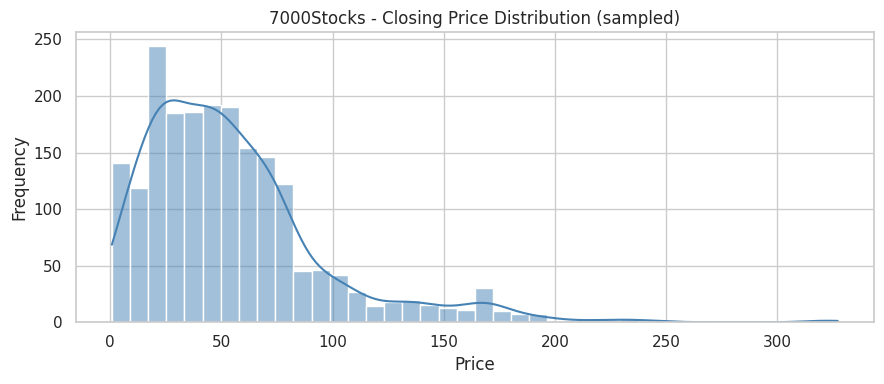

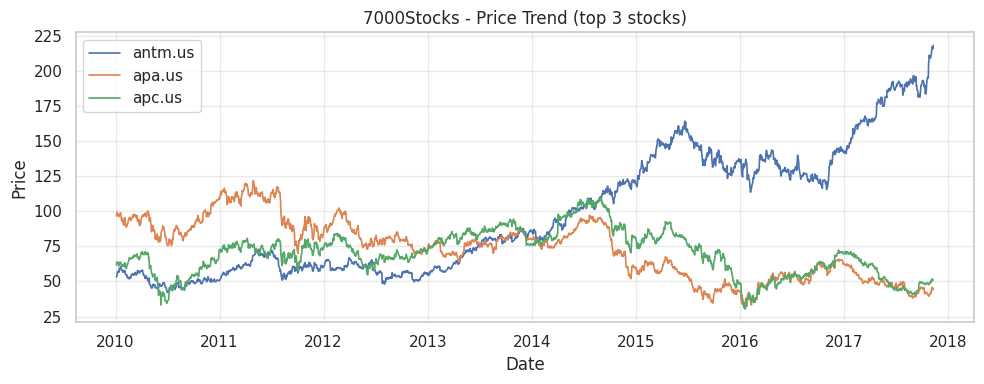


--- Summary for NIFTY50 ---
             Close
count  112400.0000
mean     1666.0903
std      3343.1953
min        60.0000
25%       349.5500
50%       721.0250
75%      1614.5500
max     32861.9500


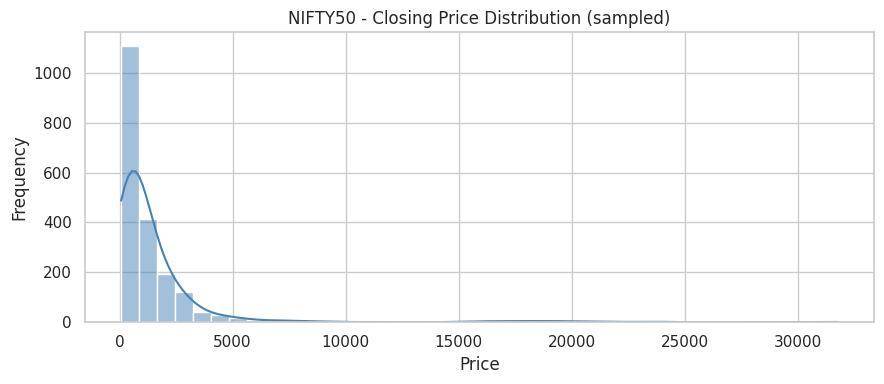

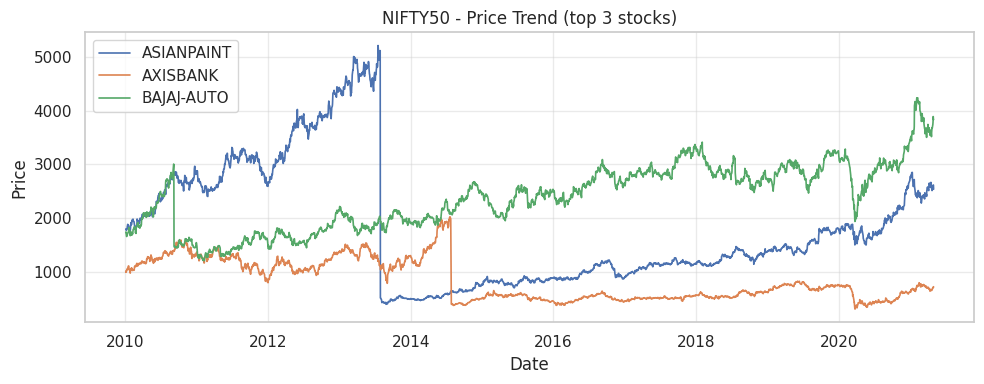


--- Summary for US500 ---
            Close
count  19960.0000
mean      83.1321
std       51.4297
min        8.7500
25%       49.1862
50%       69.8150
75%      101.4300
max      336.6400


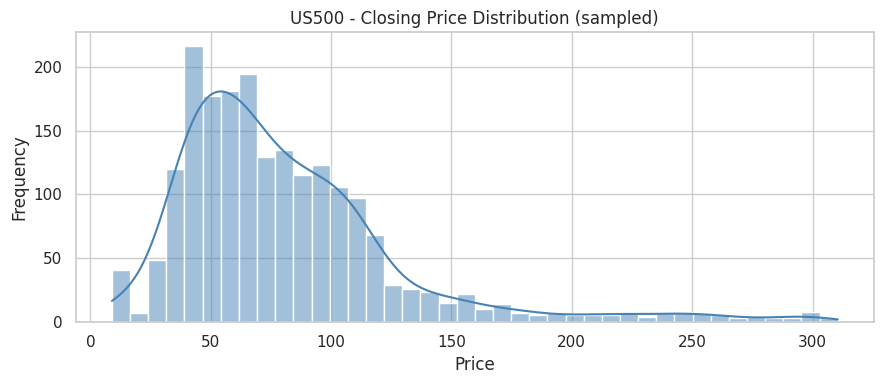

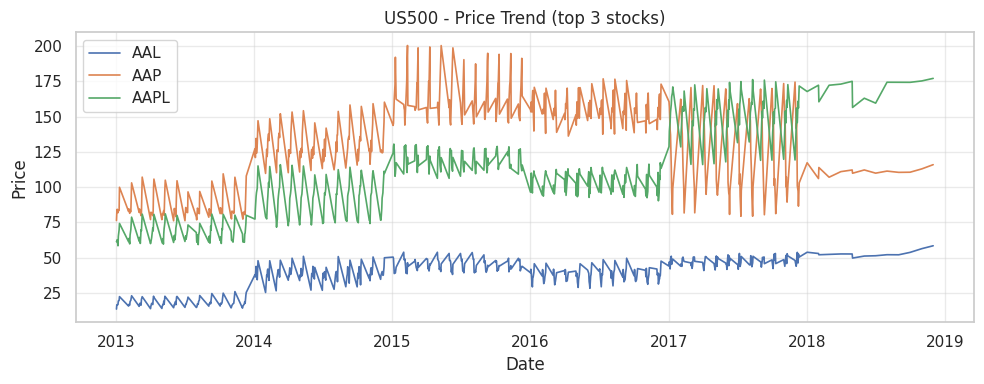

In [5]:
# =========================================
# 2B. INDIVIDUAL DATASET ANALYSIS (EDA)
# =========================================
def individual_dataset_analysis(individual_datasets, max_points=2_000, top_stocks=3):
    sns.set_theme(style='whitegrid')

    if not individual_datasets:
        print('No datasets available for EDA. Check Cell 3.')
        return

    for name, df in individual_datasets.items():
        print(f'\n--- Summary for {name} ---')
        print(df[['Close']].describe().round(4).to_string())

        sample_df = df.sample(min(len(df), max_points), random_state=42).sort_values('Date')
        plt.figure(figsize=(9, 4))
        sns.histplot(sample_df['Close'], bins=40, kde=True, color='steelblue')
        plt.title(f'{name} - Closing Price Distribution (sampled)')
        plt.xlabel('Price')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
        plt.close()

        plt.figure(figsize=(10, 4))
        for stock in df['Stock'].value_counts().head(top_stocks).index:
            stock_df = df[df['Stock'] == stock].sort_values('Date')
            if len(stock_df) > max_points:
                stock_df = stock_df.iloc[:: max(1, len(stock_df) // max_points)]
            plt.plot(stock_df['Date'], stock_df['Close'], label=stock, linewidth=1.2)
        plt.title(f'{name} - Price Trend (top {top_stocks} stocks)')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()
        plt.close()

if RUN_EDA:
    individual_dataset_analysis(individual_datasets)
else:
    print('EDA skipped. Set RUN_EDA=True in Cell 3 to generate sampled EDA plots.')


In [6]:
# =========================================
# 3. PREPROCESSING & DATALOADERS
# =========================================
print('\nPreparing chronological train/test split...')

unique_dates = combined_df['Date'].sort_values().unique()
split_index = int(len(unique_dates) * SPLIT_FRACTION)
split_index = min(max(split_index, 1), len(unique_dates) - 1)
DYNAMIC_SPLIT_DATE = unique_dates[split_index]
print(f'Calculated split date: {pd.to_datetime(DYNAMIC_SPLIT_DATE).strftime("%Y-%m-%d")} ({SPLIT_FRACTION:.0%} date split)')

train_df = combined_df[combined_df['Date'] < DYNAMIC_SPLIT_DATE].copy()
test_df = combined_df[combined_df['Date'] >= DYNAMIC_SPLIT_DATE].copy()

def compute_log_returns(close_values, previous_close=None):
    close_values = np.asarray(close_values, dtype=np.float64)
    safe_close = np.clip(close_values, 1e-8, None)
    returns = np.zeros_like(safe_close, dtype=np.float64)

    if len(safe_close) == 0:
        return returns

    if previous_close is not None and np.isfinite(previous_close) and previous_close > 0:
        returns[0] = np.log(safe_close[0] / max(previous_close, 1e-8))

    if len(safe_close) > 1:
        returns[1:] = np.diff(np.log(safe_close))

    return returns

print('Applying per-stock scaling and return features...')

for frame in (train_df, test_df):
    frame['Close_Scaled'] = np.nan
    frame['Return_Scaled'] = np.nan

scalers = {}
return_stats = {}

for stock, stock_train in train_df.groupby('Stock', sort=False):
    stock_train = stock_train.sort_values('Date')
    train_idx = stock_train.index
    train_close = stock_train['Close'].to_numpy(dtype=np.float64)

    if len(train_close) <= WINDOW + 1:
        continue

    close_scaler = MinMaxScaler()
    train_df.loc[train_idx, 'Close_Scaled'] = close_scaler.fit_transform(train_close.reshape(-1, 1)).ravel()
    scalers[stock] = close_scaler

    train_returns = compute_log_returns(train_close)
    ret_mu = float(np.nanmean(train_returns))
    ret_sigma = float(np.nanstd(train_returns))

    if not np.isfinite(ret_sigma) or ret_sigma < 1e-8:
        ret_sigma = 1.0

    return_stats[stock] = (ret_mu, ret_sigma)
    train_df.loc[train_idx, 'Return_Scaled'] = np.clip((train_returns - ret_mu) / ret_sigma, -5, 5)

    stock_test = test_df[test_df['Stock'] == stock].sort_values('Date')
    if not stock_test.empty:
        test_idx = stock_test.index
        test_close = stock_test['Close'].to_numpy(dtype=np.float64)

        test_df.loc[test_idx, 'Close_Scaled'] = close_scaler.transform(test_close.reshape(-1, 1)).ravel()

        test_returns = compute_log_returns(test_close, previous_close=train_close[-1])
        test_df.loc[test_idx, 'Return_Scaled'] = np.clip((test_returns - ret_mu) / ret_sigma, -5, 5)

train_df = train_df.dropna(subset=['Close_Scaled', 'Return_Scaled']).sort_values(['Stock', 'Date'])
test_df = test_df.dropna(subset=['Close_Scaled', 'Return_Scaled']).sort_values(['Stock', 'Date'])

def add_technical_features(df):
    df = df.sort_values(['Stock', 'Date']).copy()
    feature_frames = []

    for stock, g in df.groupby('Stock', sort=False):
        g = g.sort_values('Date').copy()

        close = g['Close_Scaled']
        ret = g['Return_Scaled']

        g['Momentum_3'] = close.diff(3)
        g['Momentum_5'] = close.diff(5)
        g['Momentum_10'] = close.diff(10)

        g['Return_Mean_5'] = ret.rolling(5, min_periods=2).mean()
        g['Return_Mean_10'] = ret.rolling(10, min_periods=2).mean()
        g['Return_Std_5'] = ret.rolling(5, min_periods=2).std()
        g['Return_Std_10'] = ret.rolling(10, min_periods=2).std()

        g['Price_MA_Diff_5'] = close - close.rolling(5, min_periods=2).mean()
        g['Price_MA_Diff_10'] = close - close.rolling(10, min_periods=2).mean()
        g['Price_MA_Diff_20'] = close - close.rolling(20, min_periods=2).mean()

        delta = close.diff()
        gain = delta.clip(lower=0).rolling(14, min_periods=2).mean()
        loss = (-delta.clip(upper=0)).rolling(14, min_periods=2).mean()
        rs = gain / (loss + 1e-8)
        g['RSI_14'] = (100 - (100 / (1 + rs))) / 100.0

        feature_frames.append(g)

    out = pd.concat(feature_frames, ignore_index=False)
    out = out.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out

train_df = add_technical_features(train_df)
test_df = add_technical_features(test_df)

FEATURE_COLUMNS = [
    'Close_Scaled',
    'Return_Scaled',
    'Momentum_3',
    'Momentum_5',
    'Momentum_10',
    'Return_Mean_5',
    'Return_Mean_10',
    'Return_Std_5',
    'Return_Std_10',
    'Price_MA_Diff_5',
    'Price_MA_Diff_10',
    'Price_MA_Diff_20',
    'RSI_14',
]

N_FEATURES = len(FEATURE_COLUMNS)
print(f'Using {N_FEATURES} input features: {FEATURE_COLUMNS}')

def create_sequences(df, window_size):
    X, y, y_prev, boundaries = [], [], [], []
    sample_idx = 0

    for stock, stock_df in df.groupby('Stock', sort=False):
        stock_df = stock_df.sort_values('Date')

        features = stock_df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        target = stock_df['Close_Scaled'].to_numpy(dtype=np.float32)

        if len(stock_df) <= window_size:
            continue

        if not np.isfinite(features).all() or not np.isfinite(target).all():
            continue

        stock_start = sample_idx

        for i in range(window_size, len(stock_df)):
            X.append(features[i - window_size:i])
            y.append(target[i])
            y_prev.append(features[i - 1, 0])
            sample_idx += 1

        if sample_idx > stock_start:
            boundaries.append((stock_start, sample_idx - 1))

    if not X:
        raise ValueError('No sequences generated. Reduce WINDOW or load more data.')

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32).reshape(-1, 1),
        np.asarray(y_prev, dtype=np.float32).reshape(-1, 1),
        boundaries,
    )

print('Generating sequences...')

X_train_np, y_train_np, y_prev_train_np, train_boundaries = create_sequences(train_df, WINDOW)
X_test_np, y_test_np, y_prev_test_np, test_boundaries = create_sequences(test_df, WINDOW)

train_moves = y_train_np.ravel() - y_prev_train_np.ravel()
nonzero_moves = np.abs(train_moves[np.abs(train_moves) > 1e-8])

DIRECTION_SCALE = float(np.median(nonzero_moves)) if len(nonzero_moves) else 1e-3
DIRECTION_SCALE = max(DIRECTION_SCALE, 1e-3)

y_delta_train_np = (y_train_np - y_prev_train_np) / DIRECTION_SCALE
y_delta_test_np = (y_test_np - y_prev_test_np) / DIRECTION_SCALE

y_delta_train_np = np.clip(y_delta_train_np, -DELTA_CLIP, DELTA_CLIP).astype(np.float32)
y_delta_test_np = y_delta_test_np.astype(np.float32)

y_actual_test = y_test_np.ravel()
y_prev_test = y_prev_test_np.ravel()

print(f'  X_train shape: {X_train_np.shape} (expected N, {WINDOW}, {N_FEATURES})')
print(f'  X_test  shape: {X_test_np.shape} (expected N, {WINDOW}, {N_FEATURES})')
print(f'  Train stocks with sequences: {len(train_boundaries)}')
print(f'  Test stocks with sequences : {len(test_boundaries)}')
print(f'  Direction scale: {DIRECTION_SCALE:.6f}')
print('  Target mode: delta / residual prediction')

pin_memory = device.type == 'cuda'
num_workers = 2 if device.type == 'cuda' else 0

def make_loader(X, y, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=pin_memory,
        num_workers=num_workers,
        persistent_workers=num_workers > 0,
    )

train_loader = make_loader(X_train_np, y_delta_train_np, BATCH_SIZE, shuffle=True)
test_loader = make_loader(X_test_np, y_delta_test_np, BATCH_SIZE, shuffle=False)

print(f'Data ready. Train batches={len(train_loader)} | Test batches={len(test_loader)}')



Preparing chronological train/test split...
Calculated split date: 2018-11-15 (80% date split)
Applying per-stock scaling and return features...
Using 13 input features: ['Close_Scaled', 'Return_Scaled', 'Momentum_3', 'Momentum_5', 'Momentum_10', 'Return_Mean_5', 'Return_Mean_10', 'Return_Std_5', 'Return_Std_10', 'Price_MA_Diff_5', 'Price_MA_Diff_10', 'Price_MA_Diff_20', 'RSI_14']
Generating sequences...
  X_train shape: (179520, 64, 13) (expected N, 64, 13)
  X_test  shape: (21760, 64, 13) (expected N, 64, 13)
  Train stocks with sequences: 120
  Test stocks with sequences : 40
  Direction scale: 0.006522
  Target mode: delta / residual prediction
Data ready. Train batches=702 | Test batches=85


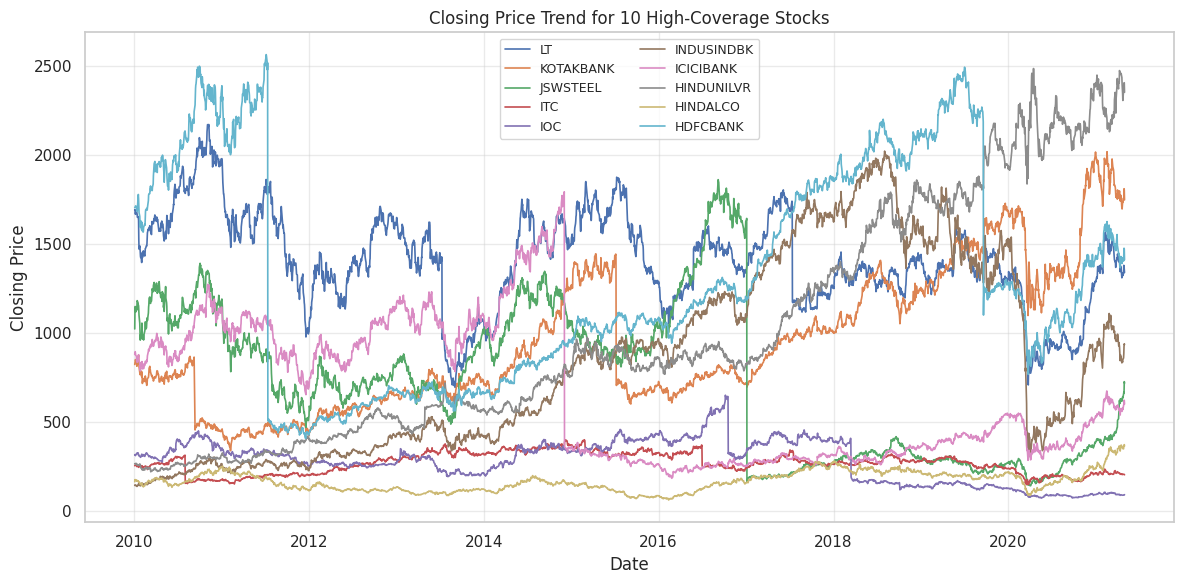

In [7]:
if RUN_PLOTS:
    plt.figure(figsize=(12, 6))
    stocks = combined_df['Stock'].value_counts().head(10).index
    for stock in stocks:
        stock_df = combined_df[combined_df['Stock'] == stock].sort_values('Date')
        if len(stock_df) > 1_500:
            stock_df = stock_df.iloc[:: max(1, len(stock_df) // 1_500)]
        plt.plot(stock_df['Date'], stock_df['Close'], label=stock, linewidth=1.2)

    plt.title('Closing Price Trend for 10 High-Coverage Stocks')
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.legend(ncol=2, fontsize=9)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print('Quick trend plot skipped. Set RUN_PLOTS=True in Cell 3 to show it.')


In [8]:
# =========================================
# 4. ARCHITECTURES
# =========================================
class RevIN(nn.Module):
    def __init__(self, num_features=1, eps=1e-5, affine=True):
        super().__init__()
        self.eps = eps
        self.affine = affine

        if affine:
            self.affine_weight = nn.Parameter(torch.ones(1, 1, num_features))
            self.affine_bias = nn.Parameter(torch.zeros(1, 1, num_features))

    def forward(self, x, mode):
        if mode == 'norm':
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.stdev = (x.var(dim=1, keepdim=True, unbiased=False) + self.eps).sqrt().detach()

            x = (x - self.mean) / self.stdev

            if self.affine:
                x = x * self.affine_weight + self.affine_bias

        elif mode == 'denorm':
            if self.affine:
                x = (x - self.affine_bias) / (self.affine_weight + self.eps)

            x = x * self.stdev + self.mean

        return x

def selective_scan(dt, A, x_ssm, B_proj, C_proj, D):
    batch_size, seq_len, d_inner = x_ssm.shape
    d_state = A.shape[1]

    A = A.to(dtype=x_ssm.dtype)
    D = D.to(dtype=x_ssm.dtype)

    h = torch.zeros(batch_size, d_inner, d_state, device=x_ssm.device, dtype=x_ssm.dtype)
    y = torch.zeros_like(x_ssm)

    for t in range(seq_len):
        dA = torch.exp(dt[:, t].unsqueeze(-1) * A)
        dB = (dt[:, t] * x_ssm[:, t]).unsqueeze(-1) * B_proj[:, t].unsqueeze(1)

        h = dA * h + dB
        y[:, t] = (h * C_proj[:, t].unsqueeze(1)).sum(-1) + D * x_ssm[:, t]

    return y

try:
    selective_scan = torch.jit.script(selective_scan)
except Exception as exc:
    print(f'TorchScript selective_scan disabled: {exc}')

class iTransformer(nn.Module):
    def __init__(self, seq_len=64, pred_len=1, channels=1, d_model=64, n_heads=None, e_layers=2):
        super().__init__()

        if n_heads is None:
            n_heads = next(h for h in [8, 4, 2, 1] if d_model % h == 0)

        assert d_model % n_heads == 0

        if globals().get('VERBOSE_MODEL_INIT', False):
            print(f'iTransformer d_model={d_model}, n_heads={n_heads}, head_dim={d_model // n_heads}')

        self.revin = RevIN(num_features=channels)
        self.project = nn.Linear(seq_len, d_model)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=n_heads,
                batch_first=True,
                dropout=0.1,
                norm_first=False,
            ),
            num_layers=e_layers,
        )

        self.predict = nn.Linear(d_model, pred_len)

    def forward(self, x):
        x = self.revin(x, 'norm')
        enc = self.encoder(self.project(x.transpose(1, 2)))

        # Output is normalized delta, not next price level.
        out = self.predict(enc)[:, 0, :]
        return out

class MambaConfig:
    def __init__(self, d_model=32, d_state=16, d_conv=4, expand=2):
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.d_inner = int(expand * d_model)
        self.dt_rank = math.ceil(d_model / 16)

class MambaBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config
        self.in_proj = nn.Linear(config.d_model, config.d_inner * 2, bias=False)

        self.conv1d = nn.Conv1d(
            config.d_inner,
            config.d_inner,
            config.d_conv,
            groups=config.d_inner,
            padding=config.d_conv - 1,
        )

        self.x_proj = nn.Linear(config.d_inner, config.dt_rank + config.d_state * 2, bias=False)
        self.dt_proj = nn.Linear(config.dt_rank, config.d_inner, bias=True)

        self.A_log = nn.Parameter(
            torch.log(torch.arange(1, config.d_state + 1, dtype=torch.float32).repeat(config.d_inner, 1))
        )

        self.D = nn.Parameter(torch.ones(config.d_inner))
        self.out_proj = nn.Linear(config.d_inner, config.d_model, bias=False)

    def forward(self, x):
        _, seq_len, _ = x.shape

        x_and_res = self.in_proj(x).transpose(1, 2)
        x_ssm, res = torch.split(x_and_res, self.config.d_inner, dim=1)

        x_ssm = F.silu(self.conv1d(x_ssm)[:, :, :seq_len]).transpose(1, 2)

        dt, B_proj, C_proj = torch.split(
            self.x_proj(x_ssm),
            [self.config.dt_rank, self.config.d_state, self.config.d_state],
            dim=-1,
        )

        dt = F.softplus(self.dt_proj(dt))
        A = -torch.exp(self.A_log.float())

        y = selective_scan(dt, A, x_ssm, B_proj, C_proj, self.D)
        return self.out_proj(y * F.silu(res.transpose(1, 2)))

class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-5):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class TimeMachine(nn.Module):
    def __init__(self, seq_len=64, pred_len=1, channels=1, d_model=32, num_layers=2):
        super().__init__()

        self.revin = RevIN(num_features=channels)
        self.feature_proj = nn.Linear(channels, d_model)

        self.config = MambaConfig(d_model=d_model)
        self.layers = nn.ModuleList([MambaBlock(self.config) for _ in range(num_layers)])
        self.norms = nn.ModuleList([RMSNorm(d_model) for _ in range(num_layers)])

        self.final_norm = RMSNorm(d_model)
        self.fc_out = nn.Linear(seq_len * d_model, pred_len)

    def forward(self, x):
        x = self.revin(x, 'norm')
        x = self.feature_proj(x)

        for block, norm in zip(self.layers, self.norms):
            x = block(norm(x)) + x

        # Output is normalized delta, not next price level.
        out = self.fc_out(self.final_norm(x).reshape(x.size(0), -1))
        return out


In [9]:
# =========================================
# 5A. FAST HYPERPARAMETER SETUP / OPTIONAL GA
# =========================================
from itertools import product
import copy
import random

SEARCH_SPACE = {
    'lr': [1e-4, 3e-4, 5e-4, 1e-3],
    'd_model': [32, 64, 128],
    'num_layers': [1, 2, 3],
}

SEARCH_KEYS = list(SEARCH_SPACE.keys())

ALL_PARAM_COMBINATIONS = [
    dict(zip(SEARCH_KEYS, values))
    for values in product(*(SEARCH_SPACE[key] for key in SEARCH_KEYS))
]

DEFAULT_TM_PARAMS = {'lr': 1e-3, 'd_model': 32, 'num_layers': 2}
DEFAULT_IT_PARAMS = {'lr': 1e-3, 'd_model': 64, 'num_layers': 2}

ga_history = {}


def individual_key(individual):
    return tuple(individual[key] for key in SEARCH_KEYS)


def create_individual(exclude_keys=None):
    exclude_keys = set(exclude_keys or set())

    candidates = [
        params
        for params in ALL_PARAM_COMBINATIONS
        if individual_key(params) not in exclude_keys
    ]

    if not candidates:
        return None

    return random.choice(candidates).copy()


def add_unique_individual(population, used_keys, individual, exclude_keys=None):
    exclude_keys = set(exclude_keys or set())

    if individual is None:
        return False

    key = individual_key(individual)

    if key in used_keys or key in exclude_keys:
        return False

    population.append(individual.copy())
    used_keys.add(key)
    return True


def create_unique_population(pop_size, exclude_keys=None, seed_individuals=None):
    exclude_keys = set(exclude_keys or set())
    pop_size = min(pop_size, len(ALL_PARAM_COMBINATIONS))

    population = []
    used_keys = set()

    for individual in seed_individuals or []:
        if len(population) >= pop_size:
            break
        add_unique_individual(population, used_keys, individual, exclude_keys)

    while (
        len(population) < pop_size
        and len(exclude_keys | used_keys) < len(ALL_PARAM_COMBINATIONS)
    ):
        individual = create_individual(exclude_keys | used_keys)
        add_unique_individual(population, used_keys, individual, exclude_keys)

    return population


def crossover(p1, p2):
    return {
        key: random.choice([p1[key], p2[key]])
        for key in SEARCH_KEYS
    }


def mutate(individual):
    mutated = individual.copy()

    key = random.choice(SEARCH_KEYS)

    possible_values = [
        value for value in SEARCH_SPACE[key]
        if value != mutated[key]
    ]

    if possible_values:
        mutated[key] = random.choice(possible_values)

    return mutated


def create_next_generation(survivors, pop_size):
    pop_size = min(pop_size, len(ALL_PARAM_COMBINATIONS))

    next_gen = []
    used_keys = set()

    for survivor in survivors:
        if len(next_gen) >= pop_size:
            break
        add_unique_individual(next_gen, used_keys, survivor)

    max_attempts = pop_size * 100
    attempts = 0

    while len(next_gen) < pop_size and attempts < max_attempts:
        attempts += 1

        if len(survivors) > 1:
            p1, p2 = random.sample(survivors, 2)
        else:
            p1, p2 = survivors[0], survivors[0]

        child = crossover(p1, p2)

        if random.random() < 0.25:
            child = mutate(child)

        add_unique_individual(next_gen, used_keys, child)

    while len(next_gen) < pop_size and len(used_keys) < len(ALL_PARAM_COMBINATIONS):
        individual = create_individual(used_keys)
        add_unique_individual(next_gen, used_keys, individual)

    return next_gen


def limited_batches(loader, max_batches=None):
    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        yield batch


def build_model(model_class, params):
    if model_class.__name__ == 'TimeMachine':
        return model_class(
            seq_len=WINDOW,
            channels=N_FEATURES,
            d_model=params['d_model'],
            num_layers=params['num_layers'],
        ).to(device)

    if model_class.__name__ == 'iTransformer':
        return model_class(
            seq_len=WINDOW,
            channels=N_FEATURES,
            d_model=params['d_model'],
            e_layers=params['num_layers'],
        ).to(device)

    return model_class(
        seq_len=WINDOW,
        channels=N_FEATURES,
    ).to(device)


def fitness_function(individual, model_class):
    try:
        model = build_model(model_class, individual)

        optimizer = optim.AdamW(
            model.parameters(),
            lr=individual['lr'],
            weight_decay=1e-4
        )

        criterion = nn.HuberLoss()

        for probe_epoch in range(GA_PROBE_EPOCHS):
            print(
                f"    GA probe epoch {probe_epoch + 1}/{GA_PROBE_EPOCHS} "
                f"| params={individual}"
            )

            model.train()

            for x, y_delta in limited_batches(train_loader, GA_TRAIN_BATCHES):
                x = x.to(device, non_blocking=True)
                y_delta = y_delta.to(device, non_blocking=True).view(-1, 1)

                optimizer.zero_grad(set_to_none=True)

                pred_delta = model(x)

                last_close = x[:, -1, 0:1]
                actual_price = last_close + y_delta * DIRECTION_SCALE
                pred_price = last_close + pred_delta * DIRECTION_SCALE

                delta_loss = criterion(pred_delta, y_delta)
                price_loss = criterion(pred_price, actual_price)

                actual_sign = torch.sign(y_delta)

                move_mask = torch.abs(y_delta) >= MOVE_THRESHOLD

                if move_mask.any():
                    direction_loss = F.softplus(
                        -(actual_sign[move_mask] * pred_delta[move_mask])
                    ).mean()
                else:
                    direction_loss = price_loss.new_tensor(0.0)

                loss = (
                    delta_loss
                    + PRICE_LOSS_WEIGHT * price_loss
                    + DIRECTION_LOSS_WEIGHT * direction_loss
                )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        model.eval()

        val_price_losses = []
        correct_direction = 0
        direction_count = 0

        with torch.no_grad():
            for x, y_delta in limited_batches(test_loader, GA_VAL_BATCHES):
                x = x.to(device, non_blocking=True)
                y_delta = y_delta.to(device, non_blocking=True).view(-1, 1)

                pred_delta = model(x)

                last_close = x[:, -1, 0:1]
                actual_price = last_close + y_delta * DIRECTION_SCALE
                pred_price = last_close + pred_delta * DIRECTION_SCALE

                val_price_losses.append(
                    criterion(pred_price, actual_price).item()
                )

                actual_sign = torch.sign(y_delta)
                pred_sign = torch.sign(pred_delta)

                move_mask = torch.abs(y_delta) >= MOVE_THRESHOLD

                if move_mask.any():
                    correct_direction += (
                        actual_sign[move_mask] == pred_sign[move_mask]
                    ).sum().item()
                    direction_count += move_mask.sum().item()

        val_price_loss = (
            float(np.mean(val_price_losses))
            if val_price_losses
            else 9999.0
        )

        val_dir_acc = (
            correct_direction / direction_count
            if direction_count
            else 0.0
        )

        fitness = 1.0 / (
            val_price_loss
            + GA_DIRECTION_FITNESS_WEIGHT * (1.0 - val_dir_acc)
            + 1e-6
        )

    except Exception as exc:
        print(f'GA candidate failed {individual}: {exc}')
        fitness = 0.0

    return fitness


def run_genetic_algorithm(
    model_class,
    model_label,
    pop_size=GA_POP_SIZE,
    generations=GA_GENERATIONS
):
    global ga_history

    max_unique = len(ALL_PARAM_COMBINATIONS)
    
    if pop_size == 'auto':
        pop_size = max(4, int(max_unique * 0.25))
        
    if generations == 'auto':
        scale_factor = 1.0
        generations = max(2, int((max_unique / pop_size) * scale_factor))

    if pop_size > max_unique:
        print(
            f'GA_POP_SIZE={pop_size} is larger than the number of unique '
            f'combinations={max_unique}. Using pop_size={max_unique}.'
        )
        pop_size = max_unique

    print('=' * 60)
    print(f'\nGA Hyperparameter Search: {model_label}')
    print('=' * 60)
    print(f'Unique hyperparameter combinations available: {max_unique}')
    print(f'Using auto-scaled Population Size: {pop_size}')
    print(f'Using auto-scaled Generations    : {generations}')

    population = create_unique_population(pop_size)

    if not population:
        raise ValueError('No unique hyperparameter combinations available.')

    fitness_cache = {}

    for gen in range(generations):
        fitness_scores = []

        print(
            f'\nGeneration {gen + 1}/{generations} '
            f'has {len(population)} unique candidates.'
        )

        for candidate_idx, ind in enumerate(population, start=1):
            key = individual_key(ind)

            print(
                f"\n  Generation {gen + 1}/{generations} "
                f"| Candidate {candidate_idx}/{len(population)} "
                f"| params={ind}"
            )

            if key in fitness_cache:
                score = fitness_cache[key]
                print(f'    Reusing cached fitness: {score:.4f}')
            else:
                score = fitness_function(ind, model_class)
                fitness_cache[key] = score

            fitness_scores.append((ind.copy(), score))

        fitness_scores.sort(key=lambda item: item[1], reverse=True)

        best_ind, best_score = fitness_scores[0]

        ga_history['fitness_best'].append(best_score)
        ga_history['fitness_avg'].append(
            float(np.mean([score for _, score in fitness_scores]))
        )
        ga_history['best_params'].append(best_ind.copy())
        ga_history['population'].append(
            [ind.copy() for ind, _ in fitness_scores]
        )

        print(
            f'  Generation {gen + 1}/{generations}: '
            f'best={best_ind}, score={best_score:.4f}'
        )

        survivors = [
            ind.copy()
            for ind, _ in fitness_scores[:max(1, pop_size // 2)]
        ]

        population = create_next_generation(survivors, pop_size)

    return fitness_scores[0][0].copy()

if RUN_GA:
    ga_history = {
        'fitness_best': [],
        'fitness_avg': [],
        'best_params': [],
        'population': [],
    }

    tm_best_params = run_genetic_algorithm(
        TimeMachine,
        'TimeMachine'
    )
    tm_history = copy.deepcopy(ga_history)

    ga_history = {
        'fitness_best': [],
        'fitness_avg': [],
        'best_params': [],
        'population': [],
    }

    it_best_params = run_genetic_algorithm(
        iTransformer,
        'iTransformer'
    )
    it_history = copy.deepcopy(ga_history)

else:
    tm_best_params = DEFAULT_TM_PARAMS.copy()
    it_best_params = DEFAULT_IT_PARAMS.copy()

    tm_history = {
        'fitness_best': [],
        'fitness_avg': [],
        'best_params': [],
        'population': [],
    }

    it_history = {
        'fitness_best': [],
        'fitness_avg': [],
        'best_params': [],
        'population': [],
    }

    print('GA skipped. Using default hyperparameters. Set RUN_GA=True in Cell 3 for tuning.')


print('\n' + '=' * 60)
print(f'TimeMachine params : {tm_best_params}')
print(f'iTransformer params: {it_best_params}')



GA Hyperparameter Search: TimeMachine
Unique hyperparameter combinations available: 36
Using auto-scaled Population Size: 9
Using auto-scaled Generations    : 4

Generation 1/4 has 9 unique candidates.

  Generation 1/4 | Candidate 1/9 | params={'lr': 0.0001, 'd_model': 128, 'num_layers': 2}
    GA probe epoch 1/2 | params={'lr': 0.0001, 'd_model': 128, 'num_layers': 2}
    GA probe epoch 2/2 | params={'lr': 0.0001, 'd_model': 128, 'num_layers': 2}

  Generation 1/4 | Candidate 2/9 | params={'lr': 0.0001, 'd_model': 32, 'num_layers': 2}
    GA probe epoch 1/2 | params={'lr': 0.0001, 'd_model': 32, 'num_layers': 2}
    GA probe epoch 2/2 | params={'lr': 0.0001, 'd_model': 32, 'num_layers': 2}

  Generation 1/4 | Candidate 3/9 | params={'lr': 0.0005, 'd_model': 32, 'num_layers': 2}
    GA probe epoch 1/2 | params={'lr': 0.0005, 'd_model': 32, 'num_layers': 2}
    GA probe epoch 2/2 | params={'lr': 0.0005, 'd_model': 32, 'num_layers': 2}

  Generation 1/4 | Candidate 4/9 | params={'lr': 


=== FINAL HYPERPARAMETERS ===
       Model     lr  d_model  num_layers
 TimeMachine 0.0010       32           2
iTransformer 0.0003       32           3


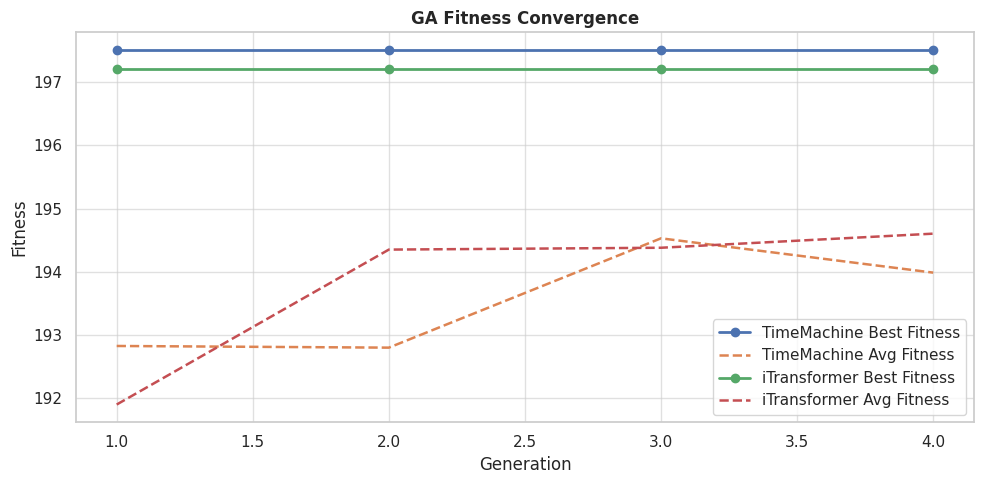

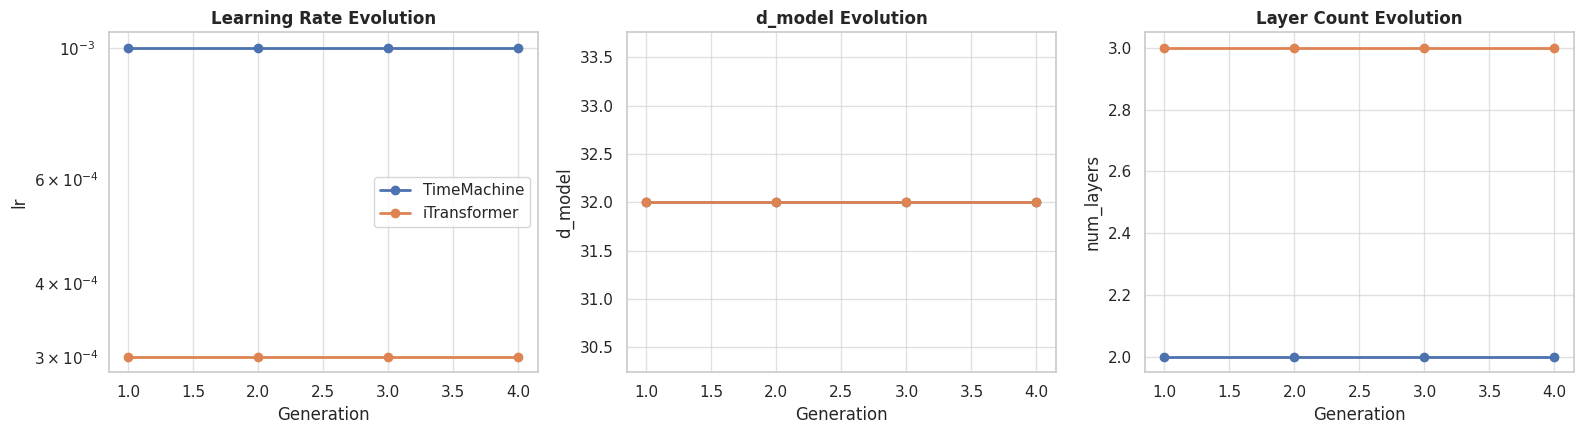

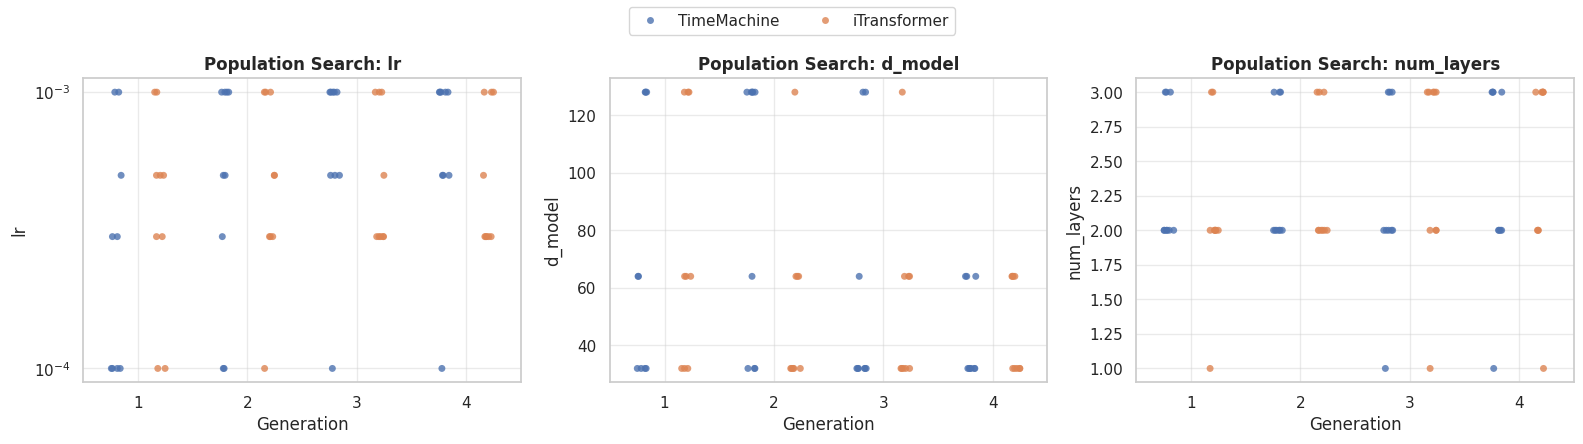

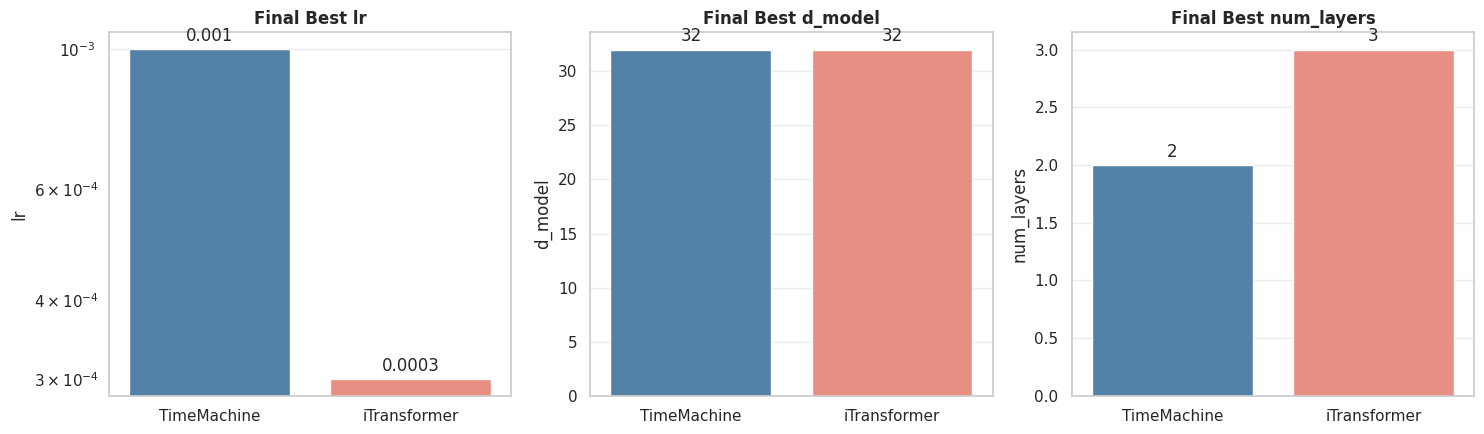

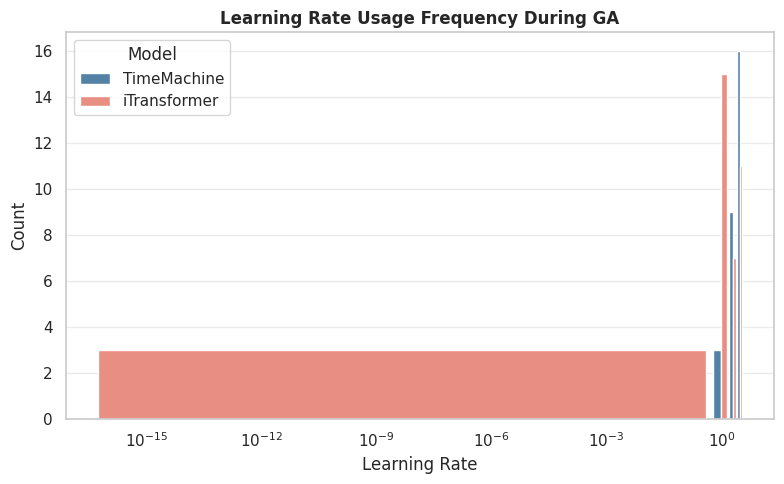


=== GA BEST PARAMETER HISTORY ===
       Model  Generation  Best_Fitness  Avg_Fitness       lr  d_model  num_layers
 TimeMachine           1    197.511928   192.821112 0.001000       32           2
 TimeMachine           2    197.511928   192.794691 0.001000       32           2
 TimeMachine           3    197.511928   194.527655 0.001000       32           2
 TimeMachine           4    197.511928   193.983813 0.001000       32           2
iTransformer           1    197.207286   191.892965 0.000300       32           3
iTransformer           2    197.207286   194.348905 0.000300       32           3
iTransformer           3    197.207286   194.378122 0.000300       32           3
iTransformer           4    197.207286   194.601530 0.000300       32           3


In [10]:
# =========================================
# 5B. GA OUTPUT VISUALIZATION
# =========================================
sns.set_theme(style='whitegrid')

def _history_to_frames(history, model_name):
    best_rows = []
    pop_rows = []

    fitness_best = history.get('fitness_best', [])
    fitness_avg = history.get('fitness_avg', [])
    best_params = history.get('best_params', [])
    population = history.get('population', [])

    for gen_idx, params in enumerate(best_params, start=1):
        best_rows.append({
            'Model': model_name,
            'Generation': gen_idx,
            'Best_Fitness': fitness_best[gen_idx - 1] if gen_idx - 1 < len(fitness_best) else np.nan,
            'Avg_Fitness': fitness_avg[gen_idx - 1] if gen_idx - 1 < len(fitness_avg) else np.nan,
            **params,
        })

    for gen_idx, gen_population in enumerate(population, start=1):
        for rank, individual in enumerate(gen_population, start=1):
            pop_rows.append({
                'Model': model_name,
                'Generation': gen_idx,
                'Rank': rank,
                **individual,
            })

    return pd.DataFrame(best_rows), pd.DataFrame(pop_rows)


def plot_all_ga_visualizations(tm_params, it_params, search_space, tm_history, it_history):
    tm_has_history = bool(tm_history.get('fitness_best'))
    it_has_history = bool(it_history.get('fitness_best'))

    final_params_df = pd.DataFrame([
        {'Model': 'TimeMachine', **tm_params},
        {'Model': 'iTransformer', **it_params},
    ])

    print('\n=== FINAL HYPERPARAMETERS ===')
    print(final_params_df.to_string(index=False))

    if not tm_has_history or not it_has_history:
        print('\nGA visualizations skipped because RUN_GA=False or no GA history is available.')
        print('Set RUN_GA=True in Cell 3, rerun Cells 8-9, then these plots will appear.')
        return

    tm_best_df, tm_pop_df = _history_to_frames(tm_history, 'TimeMachine')
    it_best_df, it_pop_df = _history_to_frames(it_history, 'iTransformer')

    best_df = pd.concat([tm_best_df, it_best_df], ignore_index=True)
    pop_df = pd.concat([tm_pop_df, it_pop_df], ignore_index=True)

    # ---------------------------------------------------------
    # 1. Fitness convergence: best vs average
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 5))

    for model_name, model_df in best_df.groupby('Model'):
        plt.plot(
            model_df['Generation'],
            model_df['Best_Fitness'],
            marker='o',
            linewidth=2,
            label=f'{model_name} Best Fitness'
        )
        plt.plot(
            model_df['Generation'],
            model_df['Avg_Fitness'],
            linestyle='--',
            linewidth=1.8,
            label=f'{model_name} Avg Fitness'
        )

    plt.title('GA Fitness Convergence', fontweight='bold')
    plt.xlabel('Generation')
    plt.ylabel('Fitness')
    plt.legend()
    plt.grid(True, alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 2. Best hyperparameter evolution
    # ---------------------------------------------------------
    keys = ['lr', 'd_model', 'num_layers']
    titles = ['Learning Rate Evolution', 'd_model Evolution', 'Layer Count Evolution']

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for ax, key, title in zip(axes, keys, titles):
        for model_name, model_df in best_df.groupby('Model'):
            ax.plot(
                model_df['Generation'],
                model_df[key],
                marker='o',
                linewidth=2,
                label=model_name
            )

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel(key)
        ax.grid(True, alpha=0.6)

        if key == 'lr':
            ax.set_yscale('log')

    axes[0].legend()
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 3. Population distribution across all generations
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for ax, key in zip(axes, keys):
        if key == 'lr':
            sns.stripplot(
                data=pop_df,
                x='Generation',
                y=key,
                hue='Model',
                dodge=True,
                jitter=True,
                alpha=0.8,
                ax=ax
            )
            ax.set_yscale('log')
        else:
            sns.stripplot(
                data=pop_df,
                x='Generation',
                y=key,
                hue='Model',
                dodge=True,
                jitter=True,
                alpha=0.8,
                ax=ax
            )

        ax.set_title(f'Population Search: {key}', fontweight='bold')
        ax.grid(True, alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    for ax in axes:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    fig.legend(handles, labels, loc='upper center', ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 4. Final best hyperparameter comparison
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for ax, key in zip(axes, keys):
        sns.barplot(
            data=final_params_df,
            x='Model',
            y=key,
            hue='Model',
            palette=['steelblue', 'salmon'],
            legend=False,
            ax=ax
        )

        ax.set_title(f'Final Best {key}', fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(key)
        ax.grid(True, axis='y', alpha=0.4)

        if key == 'lr':
            ax.set_yscale('log')

        for container in ax.containers:
            ax.bar_label(container, fmt='%.4g', padding=3)

    plt.tight_layout()
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 5. Learning-rate usage frequency
    # ---------------------------------------------------------
    lr_counts = (
        pop_df
        .groupby(['Model', 'lr'])
        .size()
        .reset_index(name='Count')
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=lr_counts,
        x='lr',
        y='Count',
        hue='Model',
        palette=['steelblue', 'salmon']
    )
    plt.xscale('log')
    plt.title('Learning Rate Usage Frequency During GA', fontweight='bold')
    plt.xlabel('Learning Rate')
    plt.ylabel('Count')
    plt.grid(True, axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 6. Best generation summary table
    # ---------------------------------------------------------
    print('\n=== GA BEST PARAMETER HISTORY ===')
    print(best_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))


plot_all_ga_visualizations(
    tm_best_params,
    it_best_params,
    SEARCH_SPACE,
    tm_history,
    it_history
)


In [11]:
# =========================================
# 6A. HELPER FUNCTIONS
# =========================================
CHECKPOINT_DIR = Path('checkpoints')

def safe_model_name(name):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', name).strip('_')

def checkpoint_path(name):
    return CHECKPOINT_DIR / f'{safe_model_name(name)}_{TARGET_MODE}_best.pth'

def save_checkpoint(model, optimizer, scheduler, name, epoch, train_losses, val_losses, best_val):
    CHECKPOINT_DIR.mkdir(exist_ok=True)

    torch.save(
        {
            'epoch': epoch + 1,
            'target_mode': TARGET_MODE,
            'direction_scale': DIRECTION_SCALE,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val': best_val,
        },
        checkpoint_path(name),
    )

def load_checkpoint(model, optimizer, scheduler, name):
    path = checkpoint_path(name)

    if not path.exists():
        print(f'  No {TARGET_MODE} checkpoint for {name}; starting fresh.')
        return 0, [], [], float('inf')

    try:
        ckpt = torch.load(path, map_location=device, weights_only=False)

        if ckpt.get('target_mode') != TARGET_MODE:
            print(f'  Checkpoint target mismatch for {name}; starting fresh.')
            return 0, [], [], float('inf')

        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])

        print(f'  Resumed {name} from epoch {ckpt["epoch"]}/{EPOCHS}')
        return ckpt['epoch'], ckpt['train_losses'], ckpt['val_losses'], ckpt.get('best_val', min(ckpt['val_losses']))

    except Exception as exc:
        print(f'  Checkpoint for {name} could not be loaded ({exc}); starting fresh.')
        return 0, [], [], float('inf')

def direction_components(y_true, y_pred, y_previous, threshold=None):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    y_previous = np.asarray(y_previous).reshape(-1)

    actual_move = y_true - y_previous
    pred_move = y_pred - y_previous

    if threshold is None:
        threshold = MOVE_THRESHOLD * DIRECTION_SCALE

    valid = np.abs(actual_move) >= threshold

    actual_dir = np.sign(actual_move[valid])
    pred_dir = np.sign(pred_move[valid])

    return actual_move, pred_move, valid, actual_dir, pred_dir


def directional_accuracy(y_true, y_pred, y_previous, threshold=None):
    _, _, valid, actual_dir, pred_dir = direction_components(
        y_true,
        y_pred,
        y_previous,
        threshold=threshold
    )

    if valid.sum() == 0:
        return 0.0

    return float(np.mean(actual_dir == pred_dir))


def run_epoch(loader, model, criterion, optimizer=None, is_train=False, max_batches=None):
    total_loss = 0.0
    total_delta_loss = 0.0
    total_price_loss = 0.0
    total_direction_loss = 0.0
    total_batches = 0

    total_sse = 0.0
    total_sae = 0.0
    total_samples = 0

    correct_direction = 0
    direction_count = 0

    for batch_idx, (batch_x, batch_delta) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        batch_x = batch_x.to(device, non_blocking=True)
        batch_delta = batch_delta.to(device, non_blocking=True).view(-1, 1)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        pred_delta = model(batch_x)

        last_close = batch_x[:, -1, 0:1]
        actual_price = last_close + batch_delta * DIRECTION_SCALE
        pred_price = last_close + pred_delta * DIRECTION_SCALE

        delta_loss = criterion(pred_delta, batch_delta)
        price_loss = criterion(pred_price, actual_price)

        model_abs_error = torch.abs(pred_price - actual_price)


        actual_sign = torch.sign(batch_delta)
        pred_sign = torch.sign(pred_delta)
        
        move_mask = torch.abs(batch_delta) >= MOVE_THRESHOLD

        if move_mask.any():
            direction_loss = F.softplus(-(actual_sign[move_mask] * pred_delta[move_mask])).mean()
            correct_direction += (actual_sign[move_mask] == pred_sign[move_mask]).sum().item()
            direction_count += move_mask.sum().item()
        else:
            direction_loss = price_loss.new_tensor(0.0)

        loss = (
            delta_loss
            + PRICE_LOSS_WEIGHT * price_loss
            + DIRECTION_LOSS_WEIGHT * direction_loss
        )

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        price_error = pred_price - actual_price
        total_sse += torch.sum(price_error.pow(2)).item()
        total_sae += torch.sum(torch.abs(price_error)).item()
        total_samples += batch_delta.numel()

        total_loss += loss.item()
        total_delta_loss += delta_loss.item()
        total_price_loss += price_loss.item()
        total_direction_loss += direction_loss.item()
        total_batches += 1

    return {
        'loss': total_loss / max(total_batches, 1),
        'delta_loss': total_delta_loss / max(total_batches, 1),
        'price_loss': total_price_loss / max(total_batches, 1),
        'direction_loss': total_direction_loss / max(total_batches, 1),
        'rmse': np.sqrt(total_sse / max(total_samples, 1)),
        'mae': total_sae / max(total_samples, 1),
        'dir_acc': correct_direction / direction_count if direction_count else 0.0,
    }


print('Helper functions ready.')


Helper functions ready.


In [12]:
# =========================================
# 6B. TRAINING FUNCTION
# =========================================
def train_and_evaluate(model, name, lr, resume=False):
    print('\n' + '=' * 55)
    print(f'Full Training: {name} | LR: {lr}')
    print('=' * 55)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=LR_REDUCE_FACTOR,
        patience=LR_REDUCE_PATIENCE - 1,
        min_lr=MIN_LR,
    )

    train_losses, val_losses = [], []

    start_epoch = 0
    best_val = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    if resume:
        start_epoch, train_losses, val_losses, best_val = load_checkpoint(model, optimizer, scheduler, name)
        best_state = copy.deepcopy(model.state_dict())

    for epoch in range(start_epoch, EPOCHS):
        model.train()
    
        train_stats = run_epoch(
            train_loader,
            model,
            criterion,
            optimizer=optimizer,
            is_train=True,
        )
    
        model.eval()
    
        with torch.no_grad():
            val_stats = run_epoch(
                test_loader,
                model,
                criterion,
                is_train=False,
            )
    
        previous_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_stats['loss'])
        current_lr = optimizer.param_groups[0]['lr']
    
        train_losses.append(train_stats['loss'])
        val_losses.append(val_stats['loss'])
    
        lr_msg = f'lr={current_lr:.6f}'
        if current_lr < previous_lr:
            lr_msg += f' reduced from {previous_lr:.6f}'
    
        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"train_loss={train_stats['loss']:.5f} | "
            f"val_loss={val_stats['loss']:.5f} | "
            f"val_rmse={val_stats['rmse']:.5f} | "
            f"val_delta={val_stats['delta_loss']:.5f} | "
            f"val_dir={val_stats['dir_acc'] * 100:.2f}% | "
            f"{lr_msg}"
        )
    
        if val_stats['loss'] < best_val - 1e-6:
            best_val = val_stats['loss']
            best_state = copy.deepcopy(model.state_dict())
    
            save_checkpoint(
                model,
                optimizer,
                scheduler,
                name,
                epoch,
                train_losses,
                val_losses,
                best_val,
            )
    
            epochs_without_improvement = 0
    
        else:
            epochs_without_improvement += 1
    
            if EARLY_STOPPING_PATIENCE is not None and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping after {epoch + 1} epochs. Best val_loss={best_val:.5f}")
                break


    model.load_state_dict(best_state)
    print(f'{name} training complete. Best val={best_val:.5f}')

    model.eval()

    all_preds, all_actuals, all_previous = [], [], []

    with torch.no_grad():
        for batch_x, batch_delta in test_loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_delta = batch_delta.to(device, non_blocking=True).view(-1, 1)

            pred_delta = model(batch_x)

            previous_price = batch_x[:, -1, 0:1]
            pred_price = previous_price + pred_delta * DIRECTION_SCALE
            actual_price = previous_price + batch_delta * DIRECTION_SCALE

            all_preds.append(pred_price.cpu().numpy())
            all_actuals.append(actual_price.cpu().numpy())
            all_previous.append(previous_price.cpu().numpy())

    y_pred = np.vstack(all_preds).reshape(-1)
    y_actual_eval = np.vstack(all_actuals).reshape(-1)
    y_previous_eval = np.vstack(all_previous).reshape(-1)

    mse = mean_squared_error(y_actual_eval, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_actual_eval, y_pred)
    r2 = r2_score(y_actual_eval, y_pred)
    dir_acc = directional_accuracy(y_actual_eval, y_pred, y_previous_eval) * 100

    metrics = {
        'RMSE': rmse,
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'Dir_Acc': dir_acc,
    }

    return model, train_losses, val_losses, y_pred, y_actual_eval, y_previous_eval, metrics

print('Training function ready.')

# =========================================
# 6C. INSTANTIATE & TRAIN BOTH MODELS
# =========================================
tm_model = TimeMachine(
    seq_len=WINDOW,
    channels=N_FEATURES,
    d_model=tm_best_params['d_model'],
    num_layers=tm_best_params['num_layers'],
).to(device)

it_model = iTransformer(
    seq_len=WINDOW,
    channels=N_FEATURES,
    d_model=it_best_params['d_model'],
    e_layers=it_best_params['num_layers'],
).to(device)

print(f'TimeMachine params : {sum(p.numel() for p in tm_model.parameters()):,}')
print(f'iTransformer params: {sum(p.numel() for p in it_model.parameters()):,}')

tm_model, tm_train, tm_val, tm_pred, y_actual, y_prev_test, tm_metrics = train_and_evaluate(
    tm_model,
    'TimeMachine',
    lr=tm_best_params['lr'],
    resume=RESUME_TRAINING,
)

it_model, it_train, it_val, it_pred, _, _, it_metrics = train_and_evaluate(
    it_model,
    'iTransformer',
    lr=it_best_params['lr'],
    resume=RESUME_TRAINING,
)

print('\nBoth models trained successfully.')


Training function ready.
TimeMachine params : 22,459
iTransformer params: 414,651

Full Training: TimeMachine | LR: 0.001
Epoch 01/15 | train_loss=1.32685 | val_loss=1.54935 | val_rmse=0.02002 | val_delta=1.37266 | val_dir=49.12% | lr=0.001000
Epoch 02/15 | train_loss=1.25496 | val_loss=1.53761 | val_rmse=0.01997 | val_delta=1.36208 | val_dir=50.58% | lr=0.001000
Epoch 03/15 | train_loss=1.20880 | val_loss=1.52862 | val_rmse=0.01992 | val_delta=1.35428 | val_dir=50.37% | lr=0.001000
Epoch 04/15 | train_loss=1.18230 | val_loss=1.52558 | val_rmse=0.01991 | val_delta=1.35162 | val_dir=50.90% | lr=0.001000
Epoch 05/15 | train_loss=1.16689 | val_loss=1.52627 | val_rmse=0.01990 | val_delta=1.35221 | val_dir=50.12% | lr=0.001000
Epoch 06/15 | train_loss=1.15645 | val_loss=1.52655 | val_rmse=0.01992 | val_delta=1.35259 | val_dir=50.73% | lr=0.001000
Epoch 07/15 | train_loss=1.14764 | val_loss=1.52662 | val_rmse=0.01991 | val_delta=1.35237 | val_dir=50.34% | lr=0.000500 reduced from 0.001000
Ep

In [13]:
# =========================================
# 6D. MODEL SELECTION & COMPARISON
# =========================================
results_df = pd.DataFrame([
    {'Model': 'TimeMachine', **tm_metrics},
    {'Model': 'iTransformer', **it_metrics},
])

assert len(tm_pred) == len(it_pred) == len(y_actual) == len(y_prev_test), 'Prediction/target lengths differ.'

print('\n=== DEEP MODEL COMPARISON ===')
print(results_df.to_string(index=False, float_format=lambda value: f'{value:.6f}'))
print('\n' + '=' * 60)

for metric in ['RMSE', 'MSE', 'MAE', 'R2', 'Dir_Acc']:
    tm_metric_value = tm_metrics[metric]
    it_metric_value = it_metrics[metric]

    if metric in ['RMSE', 'MSE', 'MAE']:
        winner = 'TimeMachine' if tm_metric_value < it_metric_value else 'iTransformer'
    else:
        winner = 'TimeMachine' if tm_metric_value > it_metric_value else 'iTransformer'

    if metric == 'Dir_Acc':
        print(f'  {metric:<10} TM={tm_metric_value:.2f}%  IT={it_metric_value:.2f}%  -> {winner}')
    else:
        print(f'  {metric:<10} TM={tm_metric_value:.6f}  IT={it_metric_value:.6f}  -> {winner}')

def composite_score(metrics_a, metrics_b):
    rmse_vals = np.array([metrics_a['RMSE'], metrics_b['RMSE']], dtype=float)
    mae_vals = np.array([metrics_a['MAE'], metrics_b['MAE']], dtype=float)
    dir_vals = np.array([metrics_a['Dir_Acc'], metrics_b['Dir_Acc']], dtype=float)

    def lower_is_better_score(vals, min_range=1e-6):
        val_range = vals.max() - vals.min()
        if val_range < min_range:
            return np.array([0.5, 0.5])
        return 1.0 - (vals - vals.min()) / val_range

    def higher_is_better_score(vals, min_range=0.50):
        val_range = vals.max() - vals.min()
        if val_range < min_range:
            return np.array([0.5, 0.5])
        return (vals - vals.min()) / val_range

    rmse_score = lower_is_better_score(rmse_vals)
    mae_score = lower_is_better_score(mae_vals)
    dir_score = higher_is_better_score(dir_vals, min_range=0.50)

    weight_rmse = 0.50
    weight_mae = 0.35
    weight_dir_acc = 0.15

    scores = (
        weight_rmse * rmse_score
        + weight_mae * mae_score
        + weight_dir_acc * dir_score
    )

    return scores[0], scores[1]

tm_score, it_score = composite_score(tm_metrics, it_metrics)

print('\n' + '=' * 60)
print(f'Composite Score -> TimeMachine: {tm_score:.4f} | iTransformer: {it_score:.4f}')

best_model_name = 'TimeMachine' if tm_score >= it_score else 'iTransformer'
print(f'BEST DEEP MODEL SELECTED: {best_model_name} (composite RMSE + directional accuracy)')

if best_model_name == 'TimeMachine':
    best_train_loss = tm_train
    best_val_loss = tm_val
    best_pred = tm_pred
    best_model_obj = tm_model
else:
    best_train_loss = it_train
    best_val_loss = it_val
    best_pred = it_pred
    best_model_obj = it_model

os.makedirs('saved_models', exist_ok=True)
save_path = f'saved_models/{best_model_name}_{TARGET_MODE}_best.pth'
torch.save(best_model_obj.state_dict(), save_path)

print(f'Model saved to {save_path}')

baseline_df = results_df.copy()



=== DEEP MODEL COMPARISON ===
       Model     RMSE      MSE      MAE       R2   Dir_Acc
 TimeMachine 0.019914 0.000397 0.011379 0.997797 50.903655
iTransformer 0.019892 0.000396 0.011339 0.997801 50.747384

  RMSE       TM=0.019914  IT=0.019892  -> iTransformer
  MSE        TM=0.000397  IT=0.000396  -> iTransformer
  MAE        TM=0.011379  IT=0.011339  -> iTransformer
  R2         TM=0.997797  IT=0.997801  -> iTransformer
  Dir_Acc    TM=50.90%  IT=50.75%  -> TimeMachine

Composite Score -> TimeMachine: 0.0750 | iTransformer: 0.9250
BEST DEEP MODEL SELECTED: iTransformer (composite RMSE + directional accuracy)
Model saved to saved_models/iTransformer_delta_best.pth


In [14]:
# =========================================
# 6F. EXPORT MODEL METADATA FOR BACKEND
# =========================================
# Saves best_model_info.json so the backend (backend.py) can
# dynamically load the correct model with the right hyperparameters.
import json as _json

selected_params = tm_best_params if best_model_name == 'TimeMachine' else it_best_params

model_info = {
    'best_model': best_model_name,
    'direction_scale': float(DIRECTION_SCALE),
    'window': WINDOW,
    'n_features': N_FEATURES,
    'feature_columns': FEATURE_COLUMNS,
    'd_model': selected_params.get('d_model', 32),
    'num_layers': selected_params.get('num_layers', 1),
}

info_path = os.path.join('saved_models', 'best_model_info.json')
with open(info_path, 'w') as f:
    _json.dump(model_info, f, indent=2)

print(f'Model metadata saved to {info_path}')
print(_json.dumps(model_info, indent=2))


Model metadata saved to saved_models/best_model_info.json
{
  "best_model": "iTransformer",
  "direction_scale": 0.006522245705127716,
  "window": 64,
  "n_features": 13,
  "feature_columns": [
    "Close_Scaled",
    "Return_Scaled",
    "Momentum_3",
    "Momentum_5",
    "Momentum_10",
    "Return_Mean_5",
    "Return_Mean_10",
    "Return_Std_5",
    "Return_Std_10",
    "Price_MA_Diff_5",
    "Price_MA_Diff_10",
    "Price_MA_Diff_20",
    "RSI_14"
  ],
  "d_model": 32,
  "num_layers": 3
}


/tmp/ipykernel_57/3005066650.py:24: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(
/tmp/ipykernel_57/3005066650.py:24: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(
/tmp/ipykernel_57/3005066650.py:24: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(
/tmp/ipykernel_57/3005066650.py:24: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(
/tmp/ipykernel_57/3005066650.py:24: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(


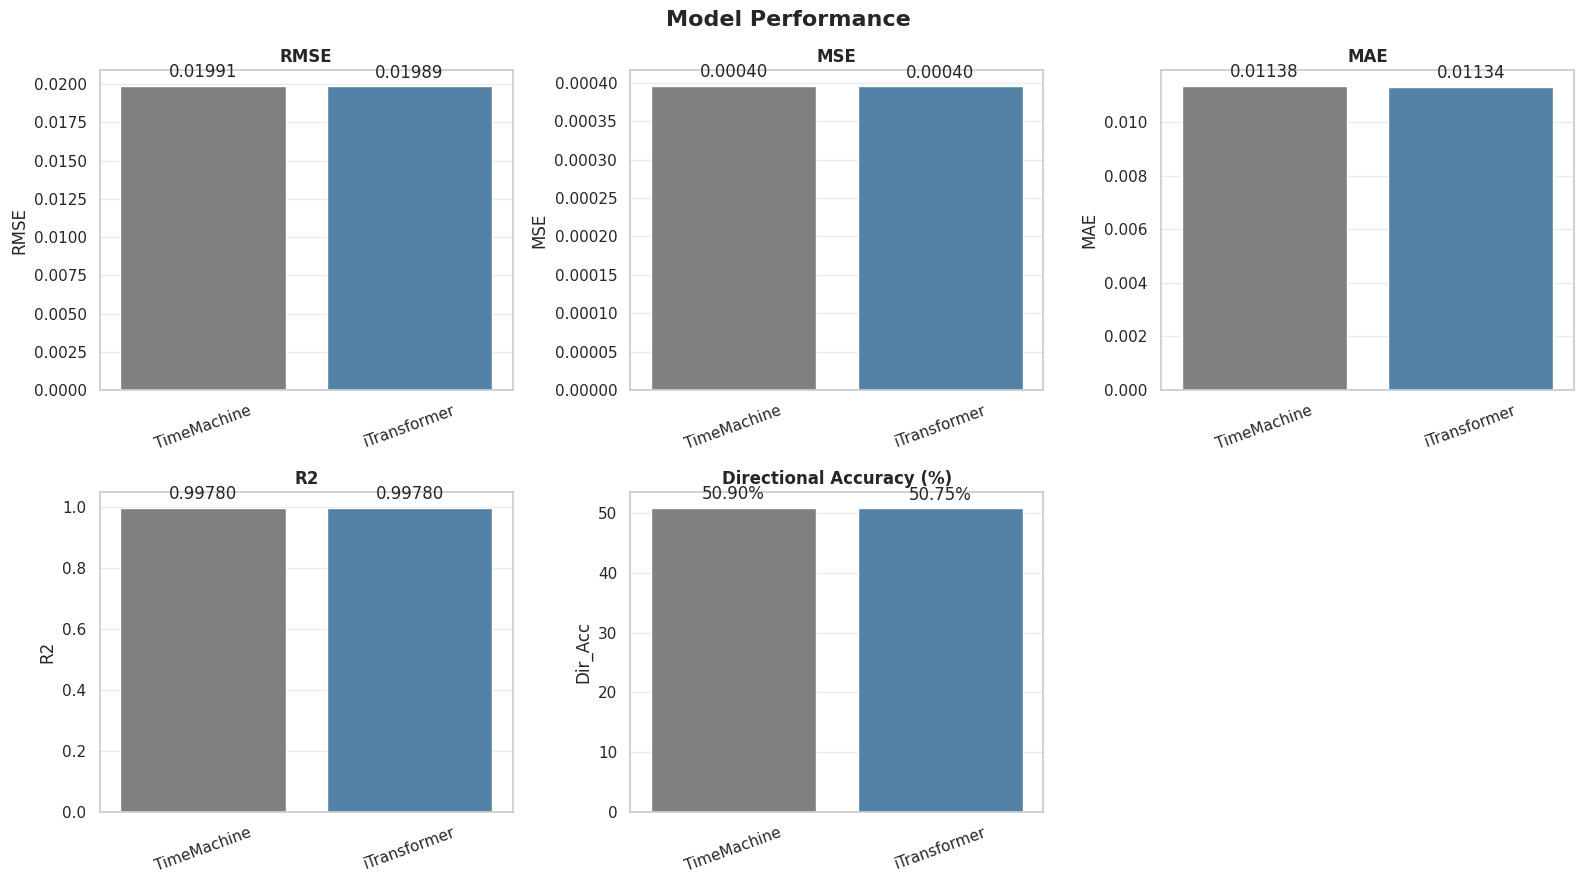

In [15]:
# =========================================
# 7A. PERFORMANCE METRICS VISUALIZATION
# =========================================
sns.set_theme(style='whitegrid')

plot_metrics_df = baseline_df.copy()

metrics_to_plot = ['RMSE', 'MSE', 'MAE', 'R2', 'Dir_Acc']
metric_titles = [
    'RMSE',
    'MSE',
    'MAE',
    'R2',
    'Directional Accuracy (%)',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

palette = ['gray', 'steelblue', 'salmon']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    sns.barplot(
        data=plot_metrics_df,
        x='Model',
        y=metric,
        hue='Model',
        palette=palette,
        legend=False,
        ax=ax
    )

    ax.set_title(metric_titles[i], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', alpha=0.4)

    for container in ax.containers:
        if metric == 'Dir_Acc':
            ax.bar_label(container, fmt='%.2f%%', padding=3)
        else:
            ax.bar_label(container, fmt='%.5f', padding=3)

axes[5].axis('off')

plt.suptitle('Model Performance ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()


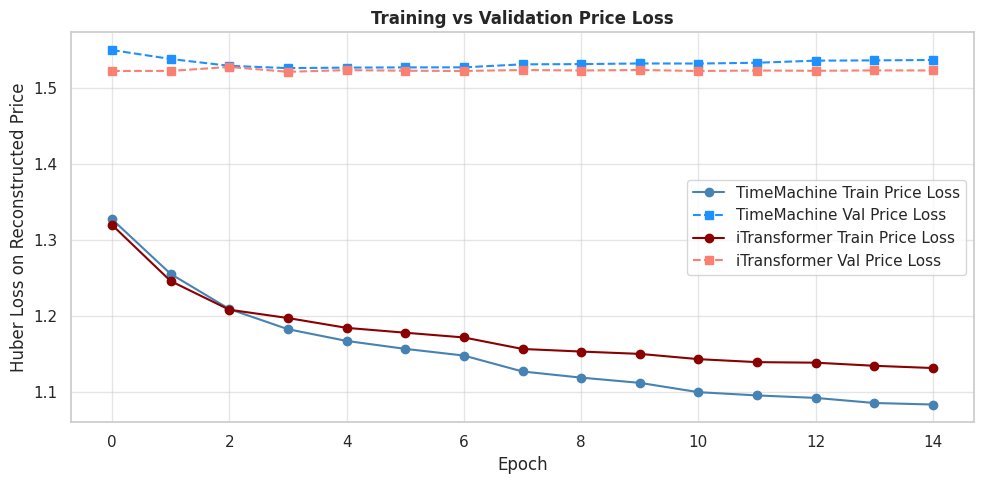

In [16]:
# =========================================
# 7B. TRAINING VS VALIDATION PRICE LOSS
# =========================================
plt.figure(figsize=(10, 5))

plt.plot(tm_train, label='TimeMachine Train Price Loss', color='steelblue', marker='o')
plt.plot(tm_val, label='TimeMachine Val Price Loss', color='dodgerblue', linestyle='--', marker='s')

plt.plot(it_train, label='iTransformer Train Price Loss', color='darkred', marker='o')
plt.plot(it_val, label='iTransformer Val Price Loss', color='salmon', linestyle='--', marker='s')

plt.title('Training vs Validation Price Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss on Reconstructed Price')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()


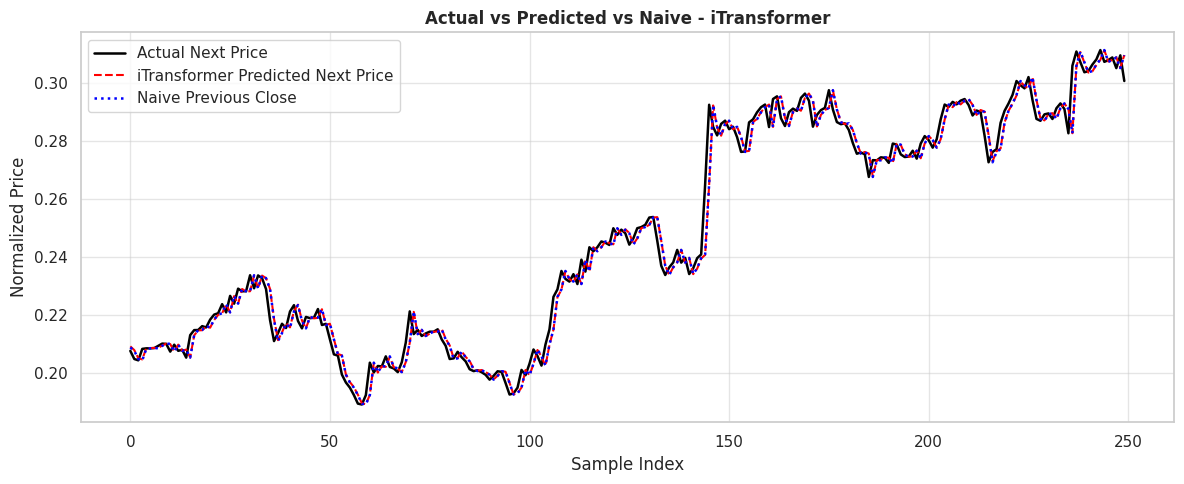

In [17]:
# =========================================
# 7C. ACTUAL VS PREDICTED VS NAIVE PRICE
# =========================================
N_SAMPLES = min(250, len(y_actual))

plt.figure(figsize=(12, 5))

plt.plot(y_actual[:N_SAMPLES], label='Actual Next Price', color='black', linewidth=1.8)
plt.plot(best_pred[:N_SAMPLES], label=f'{best_model_name} Predicted Next Price', color='red', linestyle='--', linewidth=1.5)


plt.title(f'Actual vs Predicted vs Naive - {best_model_name}', fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()


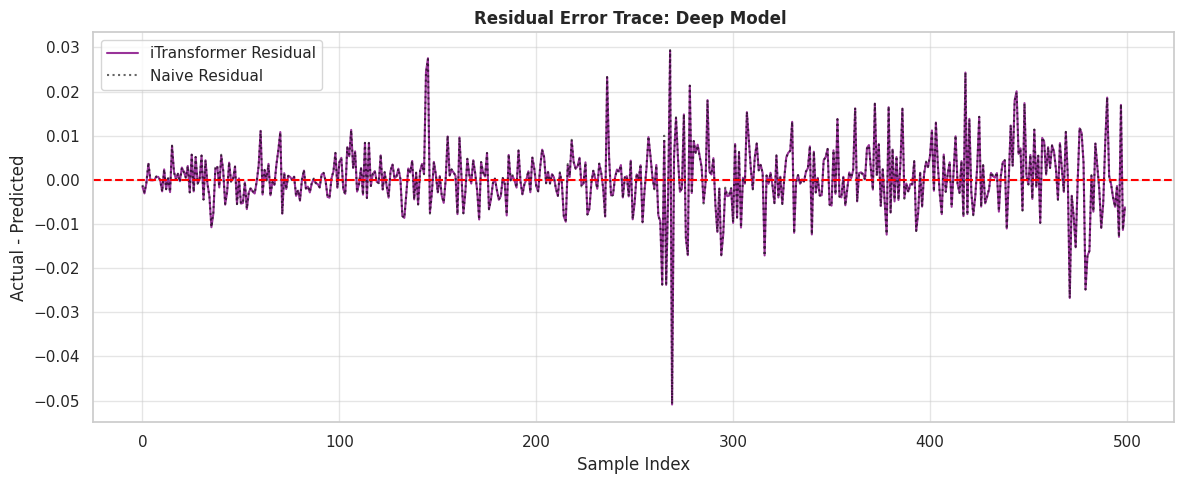

In [18]:
# =========================================
# 7D. RESIDUAL ERROR COMPARISON
# =========================================
best_residuals = y_actual - best_pred
naive_residuals = y_actual - y_prev_test

N_RESIDUAL = min(500, len(y_actual))

plt.figure(figsize=(12, 5))

plt.plot(best_residuals[:N_RESIDUAL], label=f'{best_model_name} Residual', color='purple', alpha=0.8)


plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residual Error Trace: Deep Model ', fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Actual - Predicted')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()


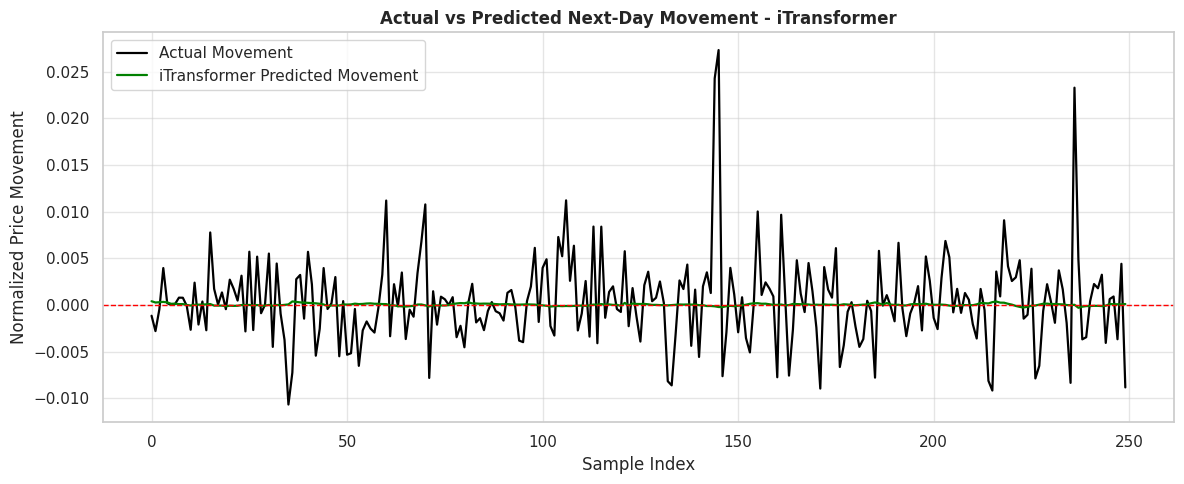

In [19]:
# =========================================
# 7E. ACTUAL VS PREDICTED PRICE MOVEMENT
# =========================================
actual_delta = y_actual - y_prev_test
pred_delta = best_pred - y_prev_test

N_DELTA = min(250, len(actual_delta))

plt.figure(figsize=(12, 5))

plt.plot(actual_delta[:N_DELTA], label='Actual Movement', color='black', linewidth=1.6)
plt.plot(pred_delta[:N_DELTA], label=f'{best_model_name} Predicted Movement', color='green', linewidth=1.6)

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title(f'Actual vs Predicted Next-Day Movement - {best_model_name}', fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Price Movement')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()
plt.close()


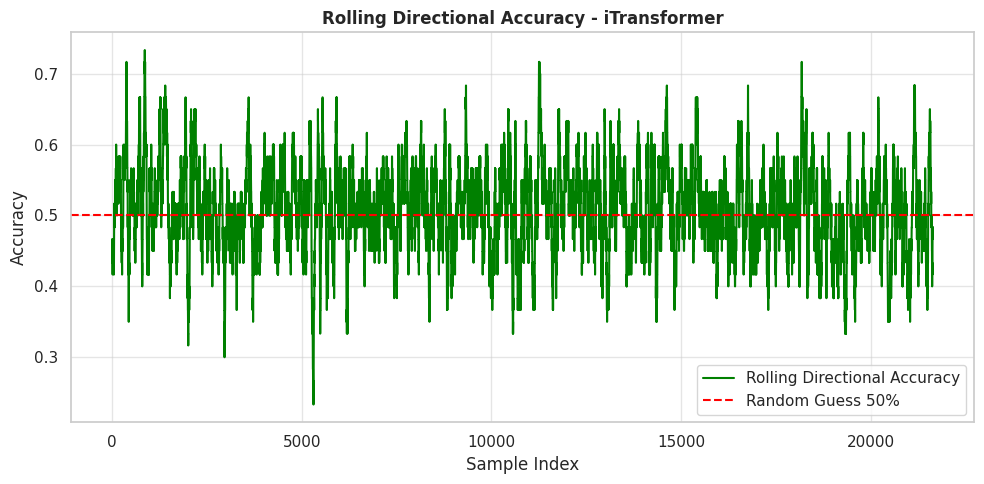

In [20]:
# =========================================
# 7F. ROLLING DIRECTIONAL ACCURACY
# =========================================
actual_direction = np.sign(y_actual - y_prev_test)
pred_direction = np.sign(best_pred - y_prev_test)

valid_direction = np.abs(y_actual - y_prev_test) > 1e-8
direction_match = (actual_direction[valid_direction] == pred_direction[valid_direction]).astype(int)

ROLLING_WINDOW = min(60, len(direction_match))

if ROLLING_WINDOW >= 2:
    rolling_acc = np.convolve(direction_match, np.ones(ROLLING_WINDOW) / ROLLING_WINDOW, mode='valid')

    plt.figure(figsize=(10, 5))
    plt.plot(rolling_acc, color='green', label='Rolling Directional Accuracy')
    plt.axhline(0.5, color='red', linestyle='--', label='Random Guess 50%')

    plt.title(f'Rolling Directional Accuracy - {best_model_name}', fontweight='bold')
    plt.xlabel('Sample Index')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print('Not enough valid direction samples for rolling accuracy plot.')


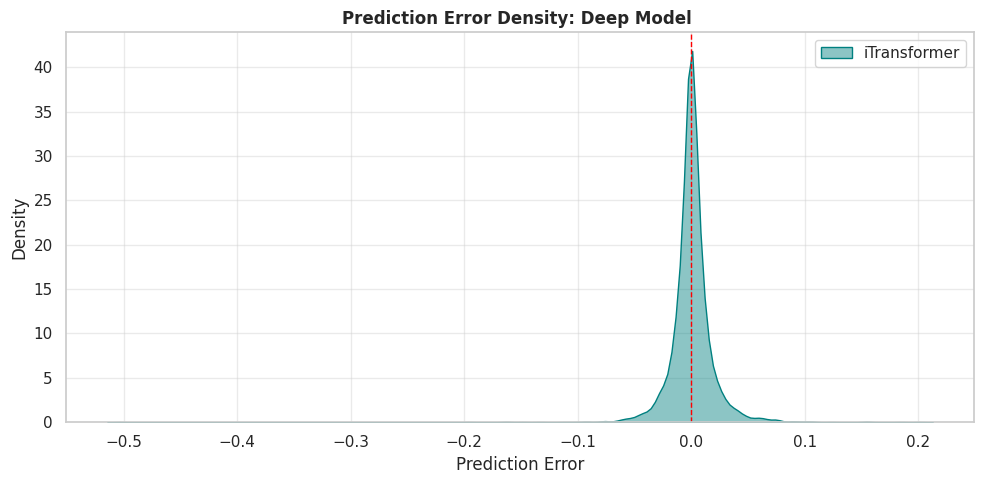

In [30]:
# =========================================
# 7G. ERROR DENSITY COMPARISON
# =========================================
max_density_samples = 5_000

if len(best_residuals) > max_density_samples:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(best_residuals), size=max_density_samples, replace=False)
    best_residual_sample = best_residuals[idx]
    naive_residual_sample = naive_residuals[idx]
else:
    best_residual_sample = best_residuals
    naive_residual_sample = naive_residuals

plt.figure(figsize=(10, 5))

sns.kdeplot(best_residual_sample, fill=True, alpha=0.45, label=best_model_name, color='teal')


plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Prediction Error Density: Deep Model ', fontweight='bold')
plt.xlabel('Prediction Error')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
plt.close()



=== Directional Metrics: TimeMachine (Multi-Dataset (Combined)) ===
Accuracy : 0.5090
Precision: 0.5111
Recall   : 0.7041
F1 Score : 0.5923


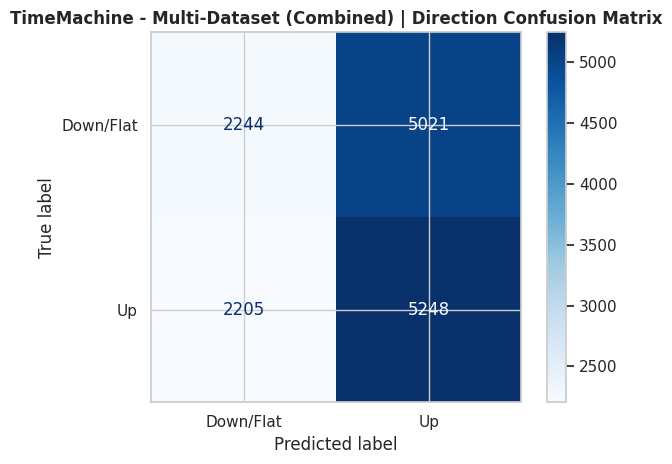

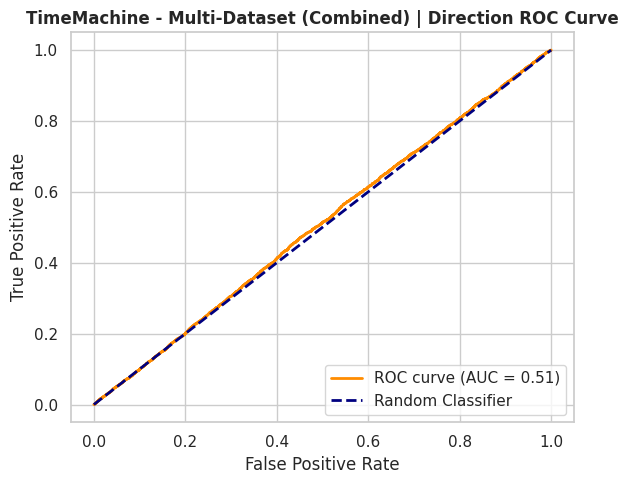

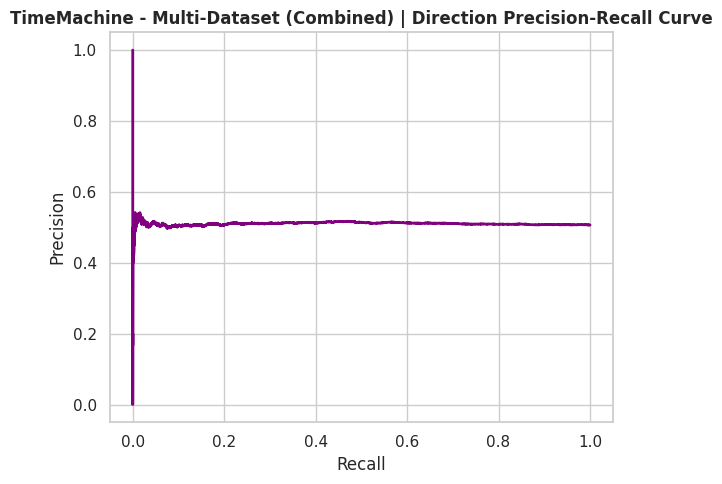


=== Directional Metrics: iTransformer (Multi-Dataset (Combined)) ===
Accuracy : 0.5075
Precision: 0.5118
Recall   : 0.5967
F1 Score : 0.5510


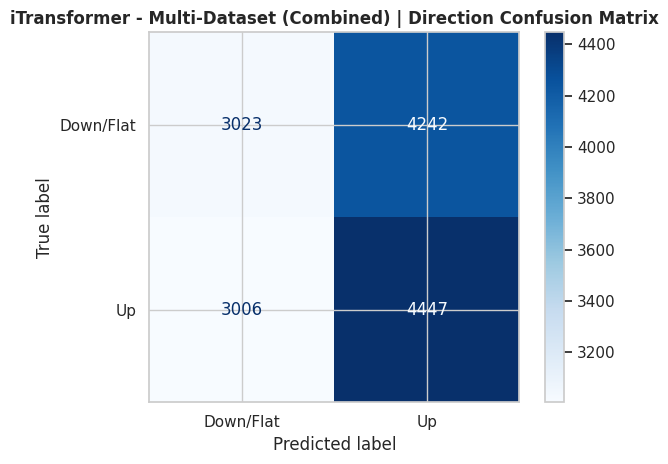

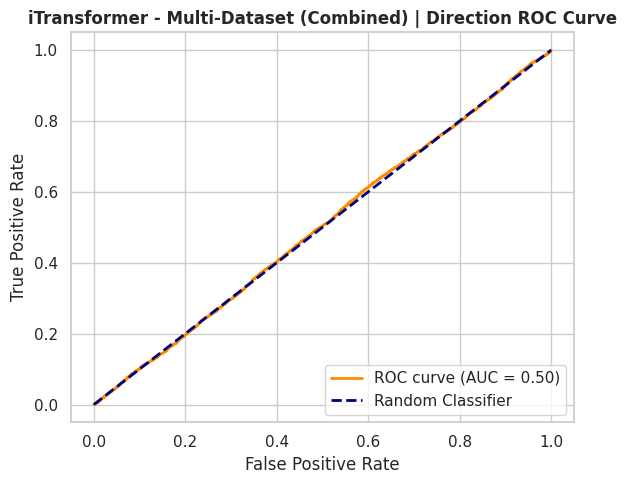

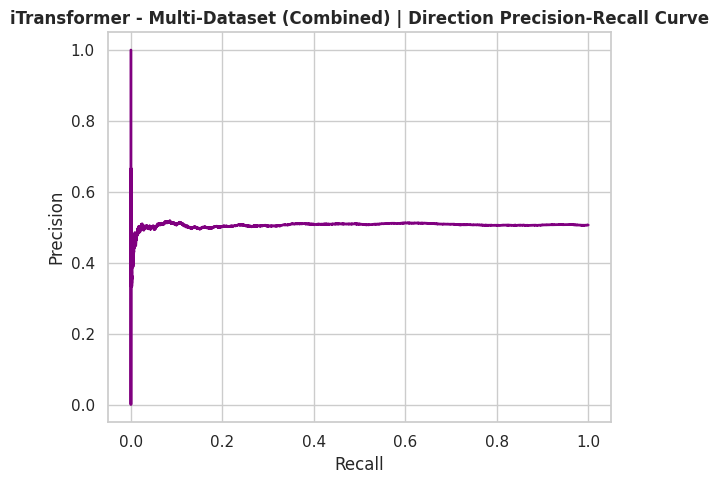

In [22]:
# =========================================
# 7H.DIRECTIONAL CLASSIFICATION EVALUATION METRICS
# =========================================
# Converts predicted next-close movement into binary up/down signals. This fixes
# the earlier price-above-mean binarization, which did not measure direction.
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)

def evaluate_directional_classification(y_true, y_pred, y_previous, dataset_name, model_name):
    actual_move, pred_move, valid, _, _ = direction_components(y_true, y_pred, y_previous)
    if valid.sum() == 0:
        print(f'{model_name}: no non-zero movement samples available.')
        return

    y_true_bin = (actual_move[valid] > 0).astype(int)
    y_pred_bin = (pred_move[valid] > 0).astype(int)
    scores = pred_move[valid]

    print(f'\n=== Directional Metrics: {model_name} ({dataset_name}) ===')
    print(f'Accuracy : {accuracy_score(y_true_bin, y_pred_bin):.4f}')
    print(f'Precision: {precision_score(y_true_bin, y_pred_bin, zero_division=0):.4f}')
    print(f'Recall   : {recall_score(y_true_bin, y_pred_bin, zero_division=0):.4f}')
    print(f'F1 Score : {f1_score(y_true_bin, y_pred_bin, zero_division=0):.4f}')

    cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down/Flat', 'Up'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{model_name} - {dataset_name} | Direction Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

    if len(np.unique(y_true_bin)) < 2:
        print('ROC/PR curves skipped because only one actual direction class is present.')
        return

    fpr, tpr, _ = roc_curve(y_true_bin, scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - {dataset_name} | Direction ROC Curve', fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    plt.close()

    precision, recall, _ = precision_recall_curve(y_true_bin, scores)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, color='purple', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} - {dataset_name} | Direction Precision-Recall Curve', fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

DATASET_LABEL = 'Multi-Dataset (Combined)'
evaluate_directional_classification(y_actual, tm_pred, y_prev_test, DATASET_LABEL, 'TimeMachine')
evaluate_directional_classification(y_actual, it_pred, y_prev_test, DATASET_LABEL, 'iTransformer')
if best_model_name not in {'TimeMachine', 'iTransformer'}:
    evaluate_directional_classification(y_actual, best_pred, y_prev_test, DATASET_LABEL, best_model_name)


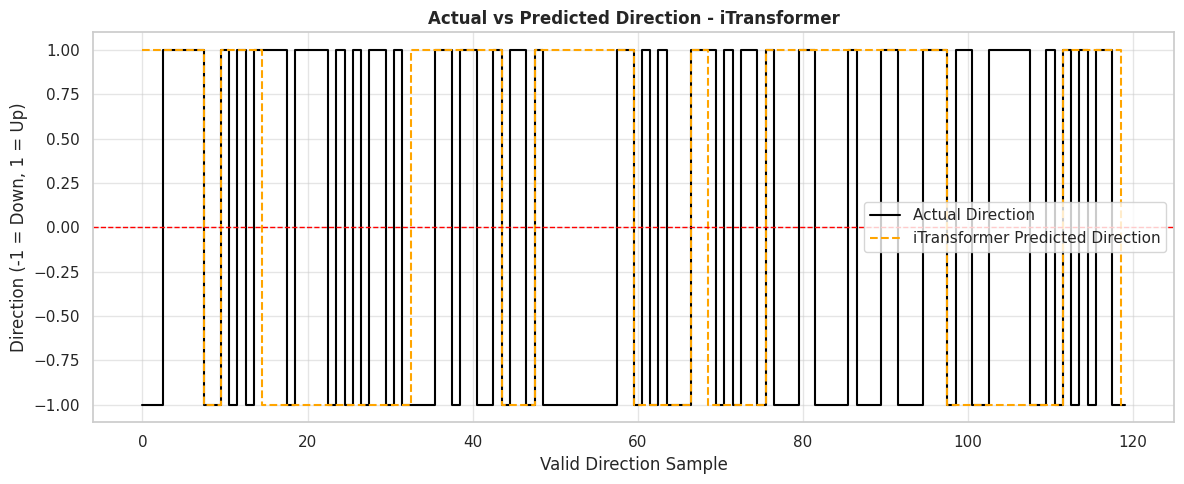

In [23]:
# =========================================
# 7I. DIRECTION MOVEMENT COMPARISON
# =========================================
N_DIR = min(120, valid_direction.sum())

if N_DIR > 0:
    valid_idx = np.where(valid_direction)[0][:N_DIR]

    plt.figure(figsize=(12, 5))

    plt.step(
        range(N_DIR),
        actual_direction[valid_idx],
        where='mid',
        label='Actual Direction',
        color='black',
        linewidth=1.5
    )

    plt.step(
        range(N_DIR),
        pred_direction[valid_idx],
        where='mid',
        label=f'{best_model_name} Predicted Direction',
        color='orange',
        linestyle='--',
        linewidth=1.5
    )

    plt.axhline(0, color='red', linestyle='--', linewidth=1)

    plt.title(f'Actual vs Predicted Direction - {best_model_name}', fontweight='bold')
    plt.xlabel('Valid Direction Sample')
    plt.ylabel('Direction (-1 = Down, 1 = Up)')
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print('No valid non-zero movement samples available for direction plot.')


In [28]:
# Updated Cell 22
# =========================================
# 7J. FUTURE STOCK PRICE FORECAST: 1 TO 5 DAYS
# =========================================
FORECAST_HORIZONS = [1, 2, 3, 4, 5]

def prepare_single_stock_features(raw_stock_df, stock):
    g = raw_stock_df.sort_values('Date').copy()

    close_values = g['Close'].to_numpy(dtype=np.float64)

    g['Close_Scaled'] = scalers[stock].transform(close_values.reshape(-1, 1)).ravel()

    ret_mu, ret_sigma = return_stats[stock]
    returns = compute_log_returns(close_values)

    g['Return_Scaled'] = np.clip((returns - ret_mu) / ret_sigma, -5, 5)

    return add_technical_features(g)

def predict_future_stock_prices(model, model_name, top_n, forecast_horizons=None):
    if forecast_horizons is None:
        forecast_horizons = FORECAST_HORIZONS

    forecast_horizons = sorted([int(h) for h in forecast_horizons])

    if not forecast_horizons or min(forecast_horizons) < 1:
        raise ValueError('forecast_horizons must contain positive integers.')

    max_horizon = max(forecast_horizons)
    forecast_horizon_set = set(forecast_horizons)
    
    # Dynamically find the index of the Close_Scaled feature
    close_feature_idx = FEATURE_COLUMNS.index('Close_Scaled')

    processed_history = (
        pd.concat([train_df, test_df], ignore_index=True)
        .sort_values(['Stock', 'Date'])
        .reset_index(drop=True)
    )

    forecasts = []
    model.eval()

    with torch.no_grad():
        for stock, stock_df in processed_history.groupby('Stock', sort=False):
            stock_df = stock_df.sort_values('Date')

            if len(stock_df) < WINDOW or stock not in scalers or stock not in return_stats:
                continue

            raw_history = stock_df[['Date', 'Close', 'Stock']].copy()

            last_actual_date = pd.to_datetime(raw_history['Date'].iloc[-1])
            last_actual_close = float(raw_history['Close'].iloc[-1])

            for step in range(1, max_horizon + 1):
                feature_history = prepare_single_stock_features(raw_history, stock)

                if len(feature_history) < WINDOW:
                    break

                feature_window = (
                    feature_history[FEATURE_COLUMNS]
                    .tail(WINDOW)
                    .to_numpy(dtype=np.float32)
                )

                if not np.isfinite(feature_window).all():
                    break

                x = torch.from_numpy(feature_window).unsqueeze(0).to(device)

                pred_delta = float(model(x).cpu().numpy().reshape(-1)[0])

                # Use the dynamically calculated index here
                last_scaled_close = float(feature_window[-1, close_feature_idx])
                
                # Corrected: using DIRECTION_SCALE instead of PRICE_DELTA_SCALE
                pred_scaled_close = last_scaled_close + pred_delta * DIRECTION_SCALE

                pred_actual_close = float(
                    scalers[stock].inverse_transform([[pred_scaled_close]])[0, 0]
                )

                forecast_date = last_actual_date + pd.offsets.BDay(step)

                if step in forecast_horizon_set:
                    predicted_change = pred_actual_close - last_actual_close

                    forecasts.append({
                        'Stock': stock,
                        'Last_Date': last_actual_date.date(),
                        'Forecast_Date': forecast_date.date(),
                        'Forecast_Horizon_BDays': step,
                        'Last_Close': last_actual_close,
                        'Predicted_Future_Close': pred_actual_close,
                        'Predicted_Change': predicted_change,
                        'Predicted_Change_%': (
                            predicted_change / last_actual_close
                        ) * 100 if last_actual_close else np.nan,
                        'Step_Normalized_Delta': pred_delta,
                        'Model': model_name,
                    })

                raw_history = pd.concat(
                    [
                        raw_history,
                        pd.DataFrame([{
                            'Date': forecast_date,
                            'Close': pred_actual_close,
                            'Stock': stock,
                        }]),
                    ],
                    ignore_index=True,
                )

    forecast_df = pd.DataFrame(forecasts)

    if forecast_df.empty:
        print('No eligible stocks available for future price forecasting.')
        return forecast_df

    selected_stocks = (
        forecast_df[['Stock', 'Last_Date']]
        .drop_duplicates()
        .sort_values(['Last_Date', 'Stock'], ascending=[False, True])
        .head(top_n)['Stock']
    )

    forecast_df = (
        forecast_df[forecast_df['Stock'].isin(selected_stocks)]
        .sort_values(['Stock', 'Forecast_Horizon_BDays'])
        .reset_index(drop=True)
    )

    print(f'\n=== Future Stock Price Forecast: 1 to {max_horizon} Business Days ({model_name}) ===')
    print(
        forecast_df.to_string(
            index=False,
            float_format=lambda value: f'{value:.4f}',
        )
    )

    return forecast_df

future_forecast_df = predict_future_stock_prices(
    best_model_obj,
    best_model_name,
    TOP_N_PER_DATASET,
    forecast_horizons=[1, 2, 3, 4, 5],
)



=== Future Stock Price Forecast: 1 to 5 Business Days (iTransformer) ===
     Stock  Last_Date Forecast_Date  Forecast_Horizon_BDays  Last_Close  Predicted_Future_Close  Predicted_Change  Predicted_Change_%  Step_Normalized_Delta        Model
ASIANPAINT 2021-04-30    2021-05-03                       1   2536.4000               2536.2079           -0.1921             -0.0076                -0.0061 iTransformer
ASIANPAINT 2021-04-30    2021-05-04                       2   2536.4000               2535.9807           -0.4193             -0.0165                -0.0072 iTransformer
ASIANPAINT 2021-04-30    2021-05-05                       3   2536.4000               2535.4315           -0.9685             -0.0382                -0.0175 iTransformer
ASIANPAINT 2021-04-30    2021-05-06                       4   2536.4000               2535.7125           -0.6875             -0.0271                 0.0089 iTransformer
ASIANPAINT 2021-04-30    2021-05-07                       5   2536.4000     


Generating SHAP explanations...
SHAP values shape: (100, 832)
Top SHAP feature: Close_Scaled_t-1

1. Global SHAP Feature Importance


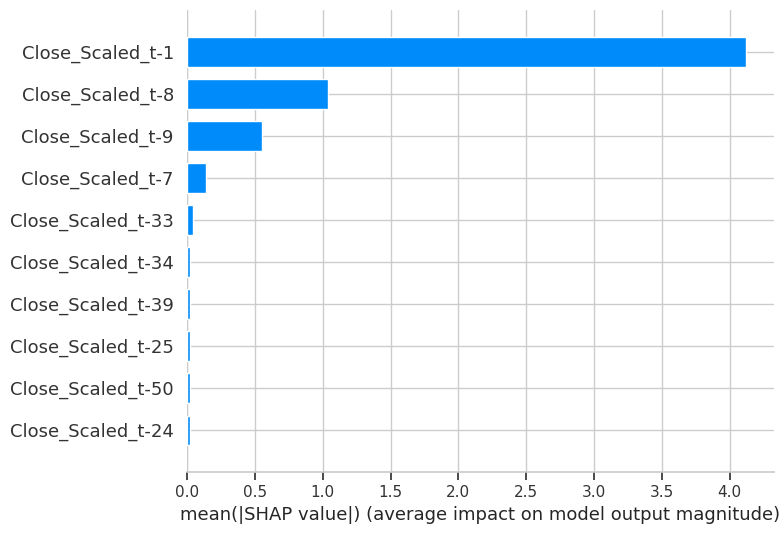


2. SHAP Beeswarm Summary Plot


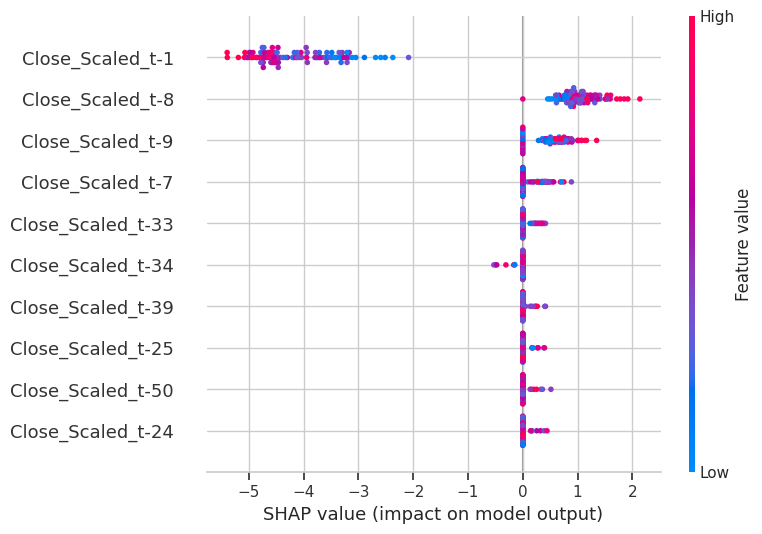


3. SHAP Heatmap


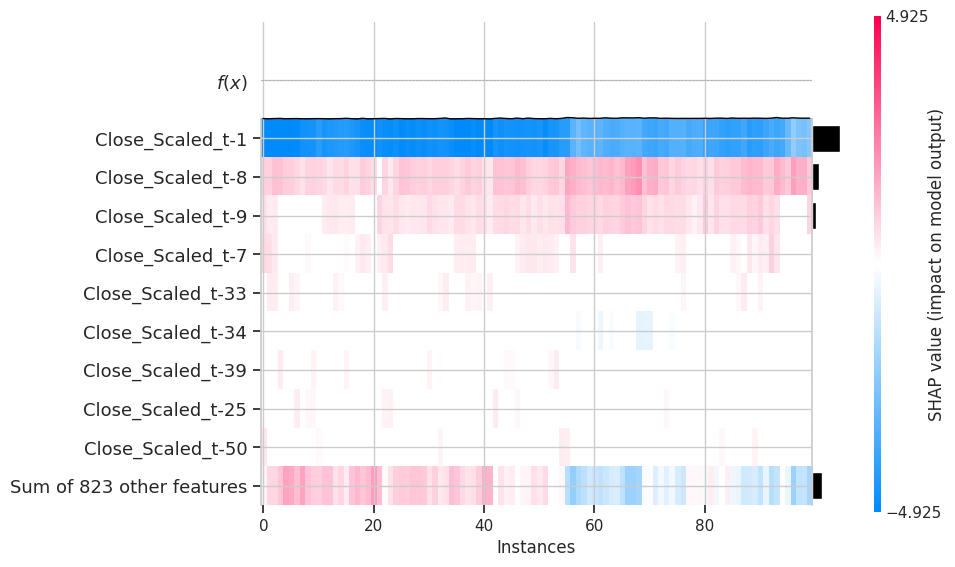


4. SHAP Waterfall Plot for One Sample


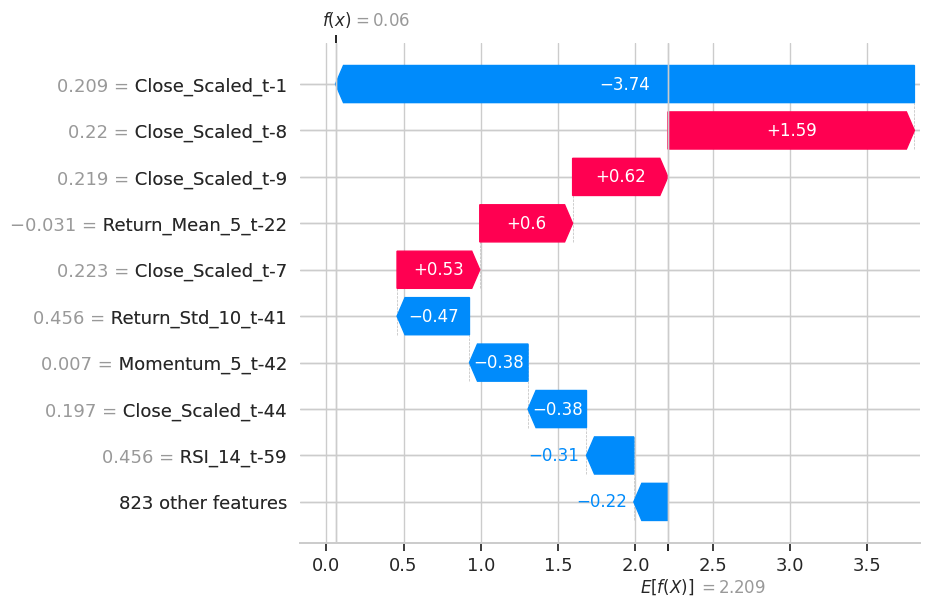


5. SHAP Decision Plot


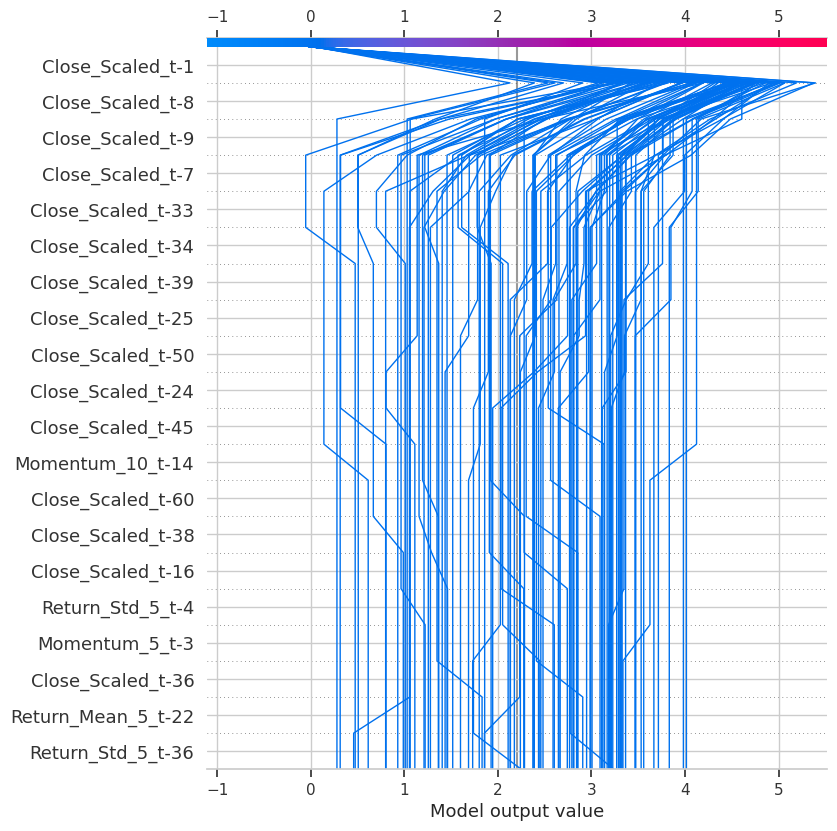


6. SHAP Dependence Plot for Top Feature


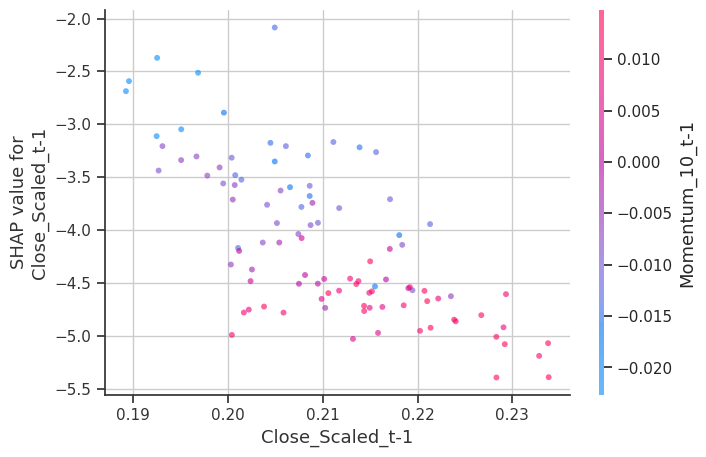


7. Lag-Wise SHAP Importance


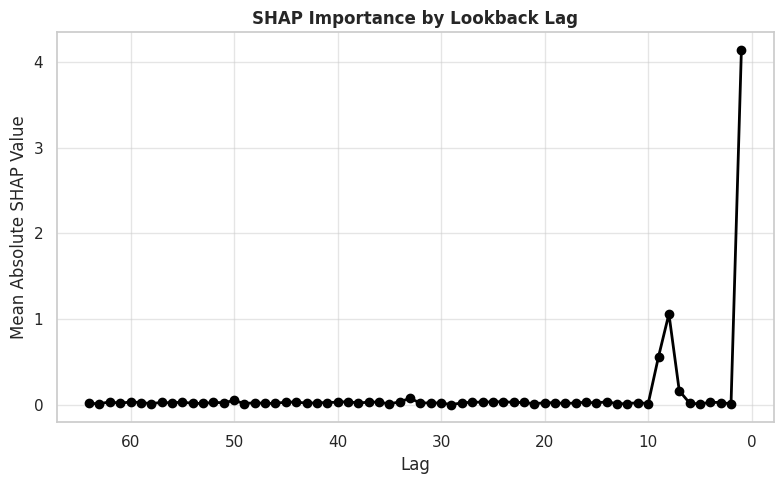


8. Feature Channel Importance


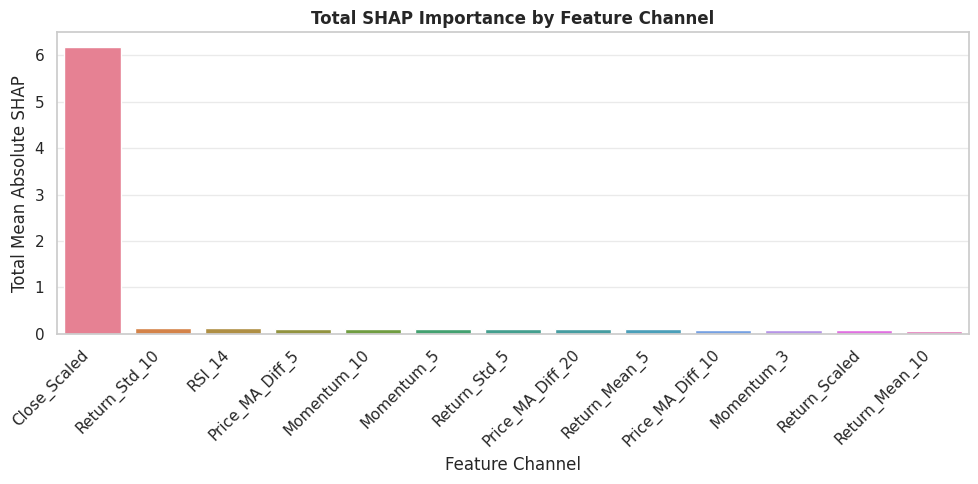


=== SHAP CHANNEL IMPORTANCE ===
 Feature_Channel  Mean_Abs_SHAP
    Close_Scaled       6.185297
   Return_Std_10       0.122022
          RSI_14       0.118889
 Price_MA_Diff_5       0.115566
     Momentum_10       0.111451
      Momentum_5       0.105416
    Return_Std_5       0.104692
Price_MA_Diff_20       0.103263
   Return_Mean_5       0.101242
Price_MA_Diff_10       0.083039
      Momentum_3       0.081001
   Return_Scaled       0.076581
  Return_Mean_10       0.064322

=== TOP SHAP FEATURES ===
           Feature  Mean_Abs_SHAP
  Close_Scaled_t-1       4.119826
  Close_Scaled_t-8       1.038106
  Close_Scaled_t-9       0.554864
  Close_Scaled_t-7       0.140053
 Close_Scaled_t-33       0.046613
 Close_Scaled_t-34       0.022731
 Close_Scaled_t-39       0.020701
 Close_Scaled_t-25       0.020285
 Close_Scaled_t-50       0.019539
 Close_Scaled_t-24       0.018806
 Close_Scaled_t-45       0.013901
  Momentum_10_t-14       0.010970
 Close_Scaled_t-60       0.010618
 Close_Scaled_t-

In [25]:
# =========================================
# EXPLAINABLE AI (OPTIONAL SHAP)
# =========================================
# Kernel SHAP is slow on deep sequence models.
# Keep RUN_SHAP=False during normal training.
# Set RUN_SHAP=True in Cell 3 only after the model is stable.

if RUN_SHAP:
    import shap
    import warnings
    from sklearn.exceptions import ConvergenceWarning

    print('\nGenerating SHAP explanations...')

    SHAP_BACKGROUND_SIZE = min(20, len(X_train_np))
    SHAP_TEST_SIZE = min(100, len(X_test_np))
    SHAP_NSAMPLES = 500
    SHAP_MAX_DISPLAY = 10
    SHAP_L1_REG = f'num_features({SHAP_MAX_DISPLAY})'

    background = X_train_np[:SHAP_BACKGROUND_SIZE]
    test_samples = X_test_np[:SHAP_TEST_SIZE]

    background_flat = background.reshape(background.shape[0], -1)
    test_flat = test_samples.reshape(test_samples.shape[0], -1)

    # Feature names now reflect all engineered input channels.
    feature_names = []
    for lag in range(WINDOW, 0, -1):
        for feature in FEATURE_COLUMNS:
            feature_names.append(f'{feature}_t-{lag}')

    def predict_fn(data):
        data = np.asarray(data, dtype=np.float32).reshape(data.shape[0], WINDOW, N_FEATURES)

        best_model_obj.eval()
        preds = []

        with torch.no_grad():
            for start in range(0, data.shape[0], 128):
                batch = torch.from_numpy(data[start:start + 128]).to(device)
                batch_preds = best_model_obj(batch).cpu().numpy()
                preds.append(batch_preds)

        return np.concatenate(preds).reshape(-1)

    # ---------------------------------------------------------
    # 1. Compute Kernel SHAP values
    # ---------------------------------------------------------
    explainer = shap.KernelExplainer(predict_fn, background_flat)

    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore',
            category=ConvergenceWarning,
            module='sklearn.linear_model._least_angle'
        )
        warnings.filterwarnings(
            'ignore',
            message='Linear regression equation is singular.*',
            category=UserWarning,
            module='shap.explainers._kernel'
        )

        try:
            shap_values = explainer.shap_values(
                test_flat,
                nsamples=SHAP_NSAMPLES,
                l1_reg=SHAP_L1_REG,
                silent=True
            )
        except TypeError:
            shap_values = explainer.shap_values(
                test_flat,
                nsamples=SHAP_NSAMPLES,
                l1_reg=SHAP_L1_REG
            )

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values.squeeze()

    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = float(np.ravel(expected_value)[0])

    shap_abs_mean = np.abs(shap_values).mean(axis=0)
    top_feature_idx = int(np.argmax(shap_abs_mean))
    top_feature_name = feature_names[top_feature_idx]

    print(f'SHAP values shape: {shap_values.shape}')
    print(f'Top SHAP feature: {top_feature_name}')

    # ---------------------------------------------------------
    # 2. Global Feature Importance: Bar Plot
    # ---------------------------------------------------------
    print('\n1. Global SHAP Feature Importance')

    shap.summary_plot(
        shap_values,
        test_flat,
        feature_names=feature_names,
        plot_type='bar',
        max_display=SHAP_MAX_DISPLAY,
        show=True
    )

    # ---------------------------------------------------------
    # 3. Beeswarm Summary Plot
    # ---------------------------------------------------------
    print('\n2. SHAP Beeswarm Summary Plot')

    shap.summary_plot(
        shap_values,
        test_flat,
        feature_names=feature_names,
        max_display=SHAP_MAX_DISPLAY,
        show=True
    )

    # ---------------------------------------------------------
    # 4. SHAP Heatmap
    # ---------------------------------------------------------
    print('\n3. SHAP Heatmap')

    try:
        explanation = shap.Explanation(
            values=shap_values,
            base_values=np.full(shap_values.shape[0], expected_value),
            data=test_flat,
            feature_names=feature_names
        )

        shap.plots.heatmap(
            explanation,
            max_display=SHAP_MAX_DISPLAY,
            show=True
        )

    except Exception as exc:
        print(f'Heatmap skipped: {exc}')

    # ---------------------------------------------------------
    # 5. Waterfall Plot for One Prediction
    # ---------------------------------------------------------
    print('\n4. SHAP Waterfall Plot for One Sample')

    sample_idx = 0

    try:
        single_explanation = shap.Explanation(
            values=shap_values[sample_idx],
            base_values=expected_value,
            data=test_flat[sample_idx],
            feature_names=feature_names
        )

        shap.plots.waterfall(
            single_explanation,
            max_display=SHAP_MAX_DISPLAY,
            show=True
        )

    except Exception as exc:
        print(f'Waterfall plot skipped: {exc}')

    # ---------------------------------------------------------
    # 6. Decision Plot
    # ---------------------------------------------------------
    print('\n5. SHAP Decision Plot')

    try:
        shap.decision_plot(
            expected_value,
            shap_values,
            test_flat,
            feature_names=feature_names,
            show=True
        )

    except Exception as exc:
        print(f'Decision plot skipped: {exc}')

    # ---------------------------------------------------------
    # 7. Dependence Plot for Most Important Feature
    # ---------------------------------------------------------
    print('\n6. SHAP Dependence Plot for Top Feature')

    try:
        shap.dependence_plot(
            top_feature_idx,
            shap_values,
            test_flat,
            feature_names=feature_names,
            alpha=0.6,
            dot_size=18,
            show=True
        )

    except Exception as exc:
        print(f'Dependence plot skipped: {exc}')

    # ---------------------------------------------------------
    # 8. Lag-wise importance across all channels
    # ---------------------------------------------------------
    print('\n7. Lag-Wise SHAP Importance')

    shap_by_lag = shap_abs_mean.reshape(WINDOW, N_FEATURES)

    lag_importance_df = pd.DataFrame({
        'Lag': list(range(WINDOW, 0, -1)),
        'Total_Importance': shap_by_lag.sum(axis=1)
    })

    plt.figure(figsize=(8, 5))
    plt.plot(
        lag_importance_df['Lag'],
        lag_importance_df['Total_Importance'],
        marker='o',
        color='black',
        linewidth=2
    )

    plt.gca().invert_xaxis()
    plt.title('SHAP Importance by Lookback Lag', fontweight='bold')
    plt.xlabel('Lag')
    plt.ylabel('Mean Absolute SHAP Value')
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close()

    # ---------------------------------------------------------
    # 9. Channel importance across engineered features
    # ---------------------------------------------------------
    print('\n8. Feature Channel Importance')

    channel_importance = pd.DataFrame({
        'Feature_Channel': FEATURE_COLUMNS,
        'Mean_Abs_SHAP': shap_by_lag.sum(axis=0)
    }).sort_values('Mean_Abs_SHAP', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=channel_importance,
        x='Feature_Channel',
        y='Mean_Abs_SHAP',
        hue='Feature_Channel',
        legend=False
    )
    plt.title('Total SHAP Importance by Feature Channel', fontweight='bold')
    plt.xlabel('Feature Channel')
    plt.ylabel('Total Mean Absolute SHAP')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()
    plt.close()

    print('\n=== SHAP CHANNEL IMPORTANCE ===')
    print(channel_importance.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

    print('\n=== TOP SHAP FEATURES ===')
    top_features_df = pd.DataFrame({
        'Feature': feature_names,
        'Mean_Abs_SHAP': shap_abs_mean
    }).sort_values('Mean_Abs_SHAP', ascending=False).head(20)

    print(top_features_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

else:
    print('SHAP skipped. Set RUN_SHAP=True in Cell 3 to run explainability visualizations.')
